# Análisis de dataset FIFA
- Juan Pablo Mosquera
- David Zahid Riveros
- Oscar Manuel Contreras Gacha
- Anderson David Arenas Gutierrez

In [53]:
#%pip uninstall pandas-profiling
#%pip install --upgrade ydata-profiling setuptools 

In [54]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Scikit-Learn preprocessing & imputation
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, RobustScaler,
    OneHotEncoder, MaxAbsScaler
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_validate

# Models & validation
from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    precision_score, recall_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Pandas config & RNG
pd.set_option("display.width", 110)
rng = np.random.default_rng(2026)
print("pandas", pd.__version__)

pandas 2.3.3


In [55]:
URL_DATASET = "https://raw.githubusercontent.com/Racsok/mineria/desarrollo/datasets/fifa_eda_stats.csv"

df = pd.read_csv(
    URL_DATASET,
    encoding="utf-8-sig",
    low_memory=False
)

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

df.head()

Filas: 18207
Columnas: 57


,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,€110.5M,€565K,Left,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,€77M,€405K,Right,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,€118.5M,€290K,Right,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,193080,De Gea,27,Spain,91,93,Manchester United,€72M,€260K,Right,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,€102M,€355K,Right,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M


## Dataset
El dataset trabaja sobre estadisticas numericas del rendimiento de jugadores de futbol dentro del FIFA, cuenta con 57 columnas y la columna objetivo sobre la cual se analizan los datos es el valor monetario de un jugador en el mercado.

link dataset: https://github.com/Racsok/mineria/blob/desarrollo/datasets/fifa_eda_stats.csv
            https://www.kaggle.com/datasets/mukeshmanral/fifa-data-for-eda-and-stats

# Perfilado y limpieza

Las columnas Value, Wage y Release Clause vienen como strings con formato tipo "€110.5M", "€565K" o "€0". Esto impide cualquier operación estadística (correlación, media, escalado) porque pandas las trata como texto. La función convert_value_to_numeric:
Devuelve None si el valor es nulo o no es string (control defensivo).

* Elimina el símbolo € y espacios.
* Si contiene 'M', multiplica el número por 1 000 000 (millones).
* Si contiene 'K', multiplica por 1 000 (miles).
* Si es exactamente "0", devuelve 0.0.
* En cualquier otro caso intenta convertirlo a float; si falla, devuelve None.

In [56]:
"""Limpieza de valores de dinero"""
def convert_value_to_numeric(value_str):
    if pd.isna(value_str) or not isinstance(value_str, str):
        return None
    value_str = value_str.replace('€', '').strip()
    if 'M' in value_str:
        return float(value_str.replace('M', '')) * 1_000_000
    elif 'K' in value_str:
        return float(value_str.replace('K', '')) * 1_000
    elif value_str == '0':
        return 0.0
    else:
        try:
            return float(value_str)
        except ValueError:
            return None
df['Value'] = df['Value'].apply(convert_value_to_numeric)
df['Wage'] = df['Wage'].apply(convert_value_to_numeric)
df['Release Clause'] = df['Release Clause'].apply(convert_value_to_numeric)

In [57]:
print(df["Value"].value_counts(normalize=True).round(3))

Value
1100000.0     0.024
375000.0      0.020
425000.0      0.019
325000.0      0.019
450000.0      0.019
              ...  
63000000.0    0.000
51500000.0    0.000
53500000.0    0.000
58000000.0    0.000
81000000.0    0.000
Name: proportion, Length: 217, dtype: float64


## Perfilado

Se Ejecuta la función de perfilado que recorre todas las columnas del DataFrame y devuelve una tabla resumen con:

* tipo: el dtype de la columna (útil para detectar numéricas disfrazadas de texto).
* distintos: número de valores únicos (nunique), para medir cardinalidad.
* faltan_%: porcentaje de nulos (isna().mean() * 100), redondeado a 1 decimal.
* moda: el valor más frecuente (s.mode().iloc[0]), con control por si la columna está vacía.
* Para columnas numéricas, además: min, mediana, media y max.

Finalmente se hace set_index("columna") para que cada fila quede identificada por el nombre de la variable. Este perfil es clave porque expone de un vistazo tres problemas: la columna Loaned From con 93.1 % de nulos, Height y Weight guardadas como strings, y Release Clause con 8.6 % de faltantes.

In [58]:
def perfilar(df):
    filas = []
    for col in df.columns:
        s = df[col]
        fila = {
            "columna":   col,
            "tipo":      str(s.dtype),
            "distintos": s.nunique(),
            "faltan_%":  round(s.isna().mean() * 100, 1),
            "moda":      s.mode().iloc[0] if not s.mode().empty else None,
        }
        if pd.api.types.is_numeric_dtype(s):
            fila["min"]     = round(s.min(), 2)
            fila["mediana"] = round(s.median(), 2)
            fila["media"]   = round(s.mean(), 2)
            fila["max"]     = round(s.max(), 2)
        filas.append(fila)
    return pd.DataFrame(filas).set_index("columna")

perfilar(df)


,tipo,distintos,faltan_%,moda,min,mediana,media,max
columna,,,,,,,,
ID,int64,18207,0.0,16,16.0,221759.0,214298.34,246620.0
Name,object,17194,0.0,J. Rodríguez,NaN,NaN,NaN,NaN
Age,int64,29,0.0,21,16.0,25.0,25.12,45.0
Nationality,object,164,0.0,England,NaN,NaN,NaN,NaN
Overall,int64,48,0.0,66,46.0,66.0,66.24,94.0
Potential,int64,47,0.0,70,48.0,71.0,71.31,95.0
Club,object,651,1.3,AS Monaco,NaN,NaN,NaN,NaN
Value,float64,217,0.0,1100000.0,0.0,675000.0,2410695.89,118500000.0
Wage,float64,144,0.0,1000.0,0.0,3000.0,9731.31,565000.0


<div id="df-812bf6ae-a487-4752-ad77-2c6b21f068fc" class="colab-df-container">
    <div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>tipo</th>
      <th>distintos</th>
      <th>faltan_%</th>
      <th>moda</th>
      <th>min</th>
      <th>mediana</th>
      <th>media</th>
      <th>max</th>
    </tr>
    <tr>
      <th>columna</th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>ID</th>
      <td>int64</td>
      <td>18207</td>
      <td>0.0</td>
      <td>16</td>
      <td>16.0</td>
      <td>221759.0</td>
      <td>214298.34</td>
      <td>246620.0</td>
    </tr>
    <tr>
      <th>Name</th>
      <td>object</td>
      <td>17194</td>
      <td>0.0</td>
      <td>J. Rodríguez</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Age</th>
      <td>int64</td>
      <td>29</td>
      <td>0.0</td>
      <td>21</td>
      <td>16.0</td>
      <td>25.0</td>
      <td>25.12</td>
      <td>45.0</td>
    </tr>
    <tr>
      <th>Nationality</th>
      <td>object</td>
      <td>164</td>
      <td>0.0</td>
      <td>England</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Overall</th>
      <td>int64</td>
      <td>48</td>
      <td>0.0</td>
      <td>66</td>
      <td>46.0</td>
      <td>66.0</td>
      <td>66.24</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>Potential</th>
      <td>int64</td>
      <td>47</td>
      <td>0.0</td>
      <td>70</td>
      <td>48.0</td>
      <td>71.0</td>
      <td>71.31</td>
      <td>95.0</td>
    </tr>
    <tr>
      <th>Club</th>
      <td>object</td>
      <td>651</td>
      <td>1.3</td>
      <td>AS Monaco</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Value</th>
      <td>object</td>
      <td>217</td>
      <td>0.0</td>
      <td>€1.1M</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Wage</th>
      <td>object</td>
      <td>144</td>
      <td>0.0</td>
      <td>€1K</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Preferred Foot</th>
      <td>object</td>
      <td>2</td>
      <td>0.3</td>
      <td>Right</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>International Reputation</th>
      <td>float64</td>
      <td>5</td>
      <td>0.3</td>
      <td>1.0</td>
      <td>1.0</td>
      <td>1.0</td>
      <td>1.11</td>
      <td>5.0</td>
    </tr>
    <tr>
      <th>Weak Foot</th>
      <td>float64</td>
      <td>5</td>
      <td>0.3</td>
      <td>3.0</td>
      <td>1.0</td>
      <td>3.0</td>
      <td>2.95</td>
      <td>5.0</td>
    </tr>
    <tr>
      <th>Skill Moves</th>
      <td>float64</td>
      <td>5</td>
      <td>0.3</td>
      <td>2.0</td>
      <td>1.0</td>
      <td>2.0</td>
      <td>2.36</td>
      <td>5.0</td>
    </tr>
    <tr>
      <th>Work Rate</th>
      <td>object</td>
      <td>9</td>
      <td>0.3</td>
      <td>Medium/ Medium</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Body Type</th>
      <td>object</td>
      <td>10</td>
      <td>0.3</td>
      <td>Normal</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Position</th>
      <td>object</td>
      <td>27</td>
      <td>0.3</td>
      <td>ST</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Jersey Number</th>
      <td>float64</td>
      <td>99</td>
      <td>0.3</td>
      <td>8.0</td>
      <td>1.0</td>
      <td>17.0</td>
      <td>19.55</td>
      <td>99.0</td>
    </tr>
    <tr>
      <th>Joined</th>
      <td>object</td>
      <td>1736</td>
      <td>8.5</td>
      <td>Jul 1, 2018</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Loaned From</th>
      <td>object</td>
      <td>341</td>
      <td>93.1</td>
      <td>Atalanta</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Contract Valid Until</th>
      <td>object</td>
      <td>36</td>
      <td>1.6</td>
      <td>2019</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Height</th>
      <td>object</td>
      <td>21</td>
      <td>0.3</td>
      <td>6'0</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Weight</th>
      <td>object</td>
      <td>57</td>
      <td>0.3</td>
      <td>165lbs</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Crossing</th>
      <td>float64</td>
      <td>89</td>
      <td>0.3</td>
      <td>62.0</td>
      <td>5.0</td>
      <td>54.0</td>
      <td>49.73</td>
      <td>93.0</td>
    </tr>
    <tr>
      <th>Finishing</th>
      <td>float64</td>
      <td>93</td>
      <td>0.3</td>
      <td>58.0</td>
      <td>2.0</td>
      <td>49.0</td>
      <td>45.55</td>
      <td>95.0</td>
    </tr>
    <tr>
      <th>HeadingAccuracy</th>
      <td>float64</td>
      <td>91</td>
      <td>0.3</td>
      <td>58.0</td>
      <td>4.0</td>
      <td>56.0</td>
      <td>52.30</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>ShortPassing</th>
      <td>float64</td>
      <td>85</td>
      <td>0.3</td>
      <td>64.0</td>
      <td>7.0</td>
      <td>62.0</td>
      <td>58.69</td>
      <td>93.0</td>
    </tr>
    <tr>
      <th>Volleys</th>
      <td>float64</td>
      <td>87</td>
      <td>0.3</td>
      <td>49.0</td>
      <td>4.0</td>
      <td>44.0</td>
      <td>42.91</td>
      <td>90.0</td>
    </tr>
    <tr>
      <th>Dribbling</th>
      <td>float64</td>
      <td>94</td>
      <td>0.3</td>
      <td>64.0</td>
      <td>4.0</td>
      <td>61.0</td>
      <td>55.37</td>
      <td>97.0</td>
    </tr>
    <tr>
      <th>Curve</th>
      <td>float64</td>
      <td>89</td>
      <td>0.3</td>
      <td>58.0</td>
      <td>6.0</td>
      <td>48.0</td>
      <td>47.17</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>FKAccuracy</th>
      <td>float64</td>
      <td>90</td>
      <td>0.3</td>
      <td>42.0</td>
      <td>3.0</td>
      <td>41.0</td>
      <td>42.86</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>LongPassing</th>
      <td>float64</td>
      <td>84</td>
      <td>0.3</td>
      <td>62.0</td>
      <td>9.0</td>
      <td>56.0</td>
      <td>52.71</td>
      <td>93.0</td>
    </tr>
    <tr>
      <th>BallControl</th>
      <td>float64</td>
      <td>90</td>
      <td>0.3</td>
      <td>65.0</td>
      <td>5.0</td>
      <td>63.0</td>
      <td>58.37</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>Acceleration</th>
      <td>float64</td>
      <td>86</td>
      <td>0.3</td>
      <td>69.0</td>
      <td>12.0</td>
      <td>67.0</td>
      <td>64.61</td>
      <td>97.0</td>
    </tr>
    <tr>
      <th>SprintSpeed</th>
      <td>float64</td>
      <td>85</td>
      <td>0.3</td>
      <td>68.0</td>
      <td>12.0</td>
      <td>67.0</td>
      <td>64.73</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>Agility</th>
      <td>float64</td>
      <td>81</td>
      <td>0.3</td>
      <td>68.0</td>
      <td>14.0</td>
      <td>66.0</td>
      <td>63.50</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>Reactions</th>
      <td>float64</td>
      <td>68</td>
      <td>0.3</td>
      <td>65.0</td>
      <td>21.0</td>
      <td>62.0</td>
      <td>61.84</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>Balance</th>
      <td>float64</td>
      <td>81</td>
      <td>0.3</td>
      <td>68.0</td>
      <td>16.0</td>
      <td>66.0</td>
      <td>63.97</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>ShotPower</th>
      <td>float64</td>
      <td>92</td>
      <td>0.3</td>
      <td>68.0</td>
      <td>2.0</td>
      <td>59.0</td>
      <td>55.46</td>
      <td>95.0</td>
    </tr>
    <tr>
      <th>Jumping</th>
      <td>float64</td>
      <td>74</td>
      <td>0.3</td>
      <td>70.0</td>
      <td>15.0</td>
      <td>66.0</td>
      <td>65.09</td>
      <td>95.0</td>
    </tr>
    <tr>
      <th>Stamina</th>
      <td>float64</td>
      <td>85</td>
      <td>0.3</td>
      <td>68.0</td>
      <td>12.0</td>
      <td>66.0</td>
      <td>63.22</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>Strength</th>
      <td>float64</td>
      <td>74</td>
      <td>0.3</td>
      <td>68.0</td>
      <td>17.0</td>
      <td>67.0</td>
      <td>65.31</td>
      <td>97.0</td>
    </tr>
    <tr>
      <th>LongShots</th>
      <td>float64</td>
      <td>92</td>
      <td>0.3</td>
      <td>59.0</td>
      <td>3.0</td>
      <td>51.0</td>
      <td>47.11</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>Aggression</th>
      <td>float64</td>
      <td>85</td>
      <td>0.3</td>
      <td>65.0</td>
      <td>11.0</td>
      <td>59.0</td>
      <td>55.87</td>
      <td>95.0</td>
    </tr>
    <tr>
      <th>Interceptions</th>
      <td>float64</td>
      <td>89</td>
      <td>0.3</td>
      <td>62.0</td>
      <td>3.0</td>
      <td>52.0</td>
      <td>46.70</td>
      <td>92.0</td>
    </tr>
    <tr>
      <th>Positioning</th>
      <td>float64</td>
      <td>94</td>
      <td>0.3</td>
      <td>58.0</td>
      <td>2.0</td>
      <td>55.0</td>
      <td>49.96</td>
      <td>95.0</td>
    </tr>
    <tr>
      <th>Vision</th>
      <td>float64</td>
      <td>85</td>
      <td>0.3</td>
      <td>58.0</td>
      <td>10.0</td>
      <td>55.0</td>
      <td>53.40</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>Penalties</th>
      <td>float64</td>
      <td>87</td>
      <td>0.3</td>
      <td>45.0</td>
      <td>5.0</td>
      <td>49.0</td>
      <td>48.55</td>
      <td>92.0</td>
    </tr>
    <tr>
      <th>Composure</th>
      <td>float64</td>
      <td>84</td>
      <td>0.3</td>
      <td>60.0</td>
      <td>3.0</td>
      <td>60.0</td>
      <td>58.65</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>Marking</th>
      <td>float64</td>
      <td>92</td>
      <td>0.3</td>
      <td>60.0</td>
      <td>3.0</td>
      <td>53.0</td>
      <td>47.28</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>StandingTackle</th>
      <td>float64</td>
      <td>90</td>
      <td>0.3</td>
      <td>66.0</td>
      <td>2.0</td>
      <td>55.0</td>
      <td>47.70</td>
      <td>93.0</td>
    </tr>
    <tr>
      <th>SlidingTackle</th>
      <td>float64</td>
      <td>88</td>
      <td>0.3</td>
      <td>62.0</td>
      <td>3.0</td>
      <td>52.0</td>
      <td>45.66</td>
      <td>91.0</td>
    </tr>
    <tr>
      <th>GKDiving</th>
      <td>float64</td>
      <td>71</td>
      <td>0.3</td>
      <td>8.0</td>
      <td>1.0</td>
      <td>11.0</td>
      <td>16.62</td>
      <td>90.0</td>
    </tr>
    <tr>
      <th>GKHandling</th>
      <td>float64</td>
      <td>70</td>
      <td>0.3</td>
      <td>10.0</td>
      <td>1.0</td>
      <td>11.0</td>
      <td>16.39</td>
      <td>92.0</td>
    </tr>
    <tr>
      <th>GKKicking</th>
      <td>float64</td>
      <td>79</td>
      <td>0.3</td>
      <td>12.0</td>
      <td>1.0</td>
      <td>11.0</td>
      <td>16.23</td>
      <td>91.0</td>
    </tr>
    <tr>
      <th>GKPositioning</th>
      <td>float64</td>
      <td>79</td>
      <td>0.3</td>
      <td>10.0</td>
      <td>1.0</td>
      <td>11.0</td>
      <td>16.39</td>
      <td>90.0</td>
    </tr>
    <tr>
      <th>GKReflexes</th>
      <td>float64</td>
      <td>76</td>
      <td>0.3</td>
      <td>10.0</td>
      <td>1.0</td>
      <td>11.0</td>
      <td>16.71</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>Release Clause</th>
      <td>object</td>
      <td>1244</td>
      <td>8.6</td>
      <td>€1.1M</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
  </tbody>
</table>
</div>
    <div class="colab-df-buttons">
      
  <div class="colab-df-container">
    <button class="colab-df-convert" onclick="convertToInteractive('df-812bf6ae-a487-4752-ad77-2c6b21f068fc')"
            title="Convert this dataframe to an interactive table."
            style="display:none;">
      
  <svg xmlns="http://www.w3.org/2000/svg" height="24px" viewBox="0 -960 960 960">
    <path d="M120-120v-720h720v720H120Zm60-500h600v-160H180v160Zm220 220h160v-160H400v160Zm0 220h160v-160H400v160ZM180-400h160v-160H180v160Zm440 0h160v-160H620v160ZM180-180h160v-160H180v160Zm440 0h160v-160H620v160Z"/>
  </svg>
    </button>
    
  <style>
    .colab-df-container {
      display:flex;
      gap: 12px;
    }

    .colab-df-convert {
      background-color: #E8F0FE;
      border: none;
      border-radius: 50%;
      cursor: pointer;
      display: none;
      fill: #1967D2;
      height: 32px;
      padding: 0 0 0 0;
      width: 32px;
    }

    .colab-df-convert:hover {
      background-color: #E2EBFA;
      box-shadow: 0px 1px 2px rgba(60, 64, 67, 0.3), 0px 1px 3px 1px rgba(60, 64, 67, 0.15);
      fill: #174EA6;
    }

    .colab-df-buttons div {
      margin-bottom: 4px;
    }

    [theme=dark] .colab-df-convert {
      background-color: #3B4455;
      fill: #D2E3FC;
    }

    [theme=dark] .colab-df-convert:hover {
      background-color: #434B5C;
      box-shadow: 0px 1px 3px 1px rgba(0, 0, 0, 0.15);
      filter: drop-shadow(0px 1px 2px rgba(0, 0, 0, 0.3));
      fill: #FFFFFF;
    }
  </style>
  </div>
  
  </div>

## Tres problemas encontrados y su solución

* **`Loaned From` con 93.1% de datos nulos:**  
  La gran mayoría de jugadores no están cedidos a préstamo, lo que genera una columna desierta de casi solo faltantes.  
  * **Solución:** Eliminar la columna por falta de varianza o convertirla en una bandera binaria `is_loaned` (1 si tiene club de origen, 0 si es `NaN`).

* **Valores numéricos guardados como texto (`Height` y `Weight`):**  
  Tienen formato de cadena tipo `6'0` y `165lbs`, lo que impide su análisis estadístico y cálculo de correlación directa.  
  * **Solución:** Aplicar una función de transformación en Pandas para convertir `Height` a centímetros y `Weight` a kilogramos (o libras numéricas) y castearlas a tipo `float64`.

* **Nulos masivos en cláusula de rescisión (`Release Clause` con 8.6% de faltantes):**  
  Existen 1,564 jugadores sin cláusula asignada en la base de datos.  
  * **Solución:** Imputar los faltantes calculando una estimación basada en la relación proporcional entre `Value` y `Overall`, o asignar 0 si el contrato no contempla dicha cláusula.

---

## Columnas objetivo y su reparto

###Numerica Value
Al ser **`Value`** una variable continua económica (target de regresión), el método `value_counts(normalize=True)` se utiliza para observar la concentración del mercado o agrupar por rangos. Su reparto estadístico directo muestra:

* **Mínimo:** €0.0
* **Mediana:** €675,000.0
* **Media:** €2,410,695.89
* **Máximo:** €118,500,000.0

*(El reparto de `Value` presenta un marcado sesgo positivo a la derecha [right-skewed], donde más del 50% de los jugadores tiene un valor de mercado inferior a €675,000, mientras que una élite de superestrellas eleva la media a €2.4M y alcanza un pico de €118.5M).*

### Categorica position
Usaremos las variables carateristicas del jufador para oredecir que posicion e jugara



## Limpieza y arreglos

### Solución al Problema 1: Columna `Loaned From` con valores nulos

Se crea una nueva columna `is_loaned` que indica si el jugador está cedido (1) o no (0). Posteriormente, se elimina la columna original `Loaned From`.

In [59]:
# Crear la columna binaria 'is_loaned': 1 si el jugador está cedido (no es NaN en 'Loaned From'), 0 en caso contrario.
df['is_loaned'] = df['Loaned From'].notna().astype(int)

# Eliminar la columna original 'Loaned From' ya que la nueva columna captura la información relevante.
df = df.drop(columns=['Loaned From'])

# Mostrar las primeras filas del DataFrame con la nueva columna y la columna eliminada
display(df[['Name', 'Club', 'is_loaned']].head())

# Verificar el tipo de datos y la ausencia de la columna original
print(df[['is_loaned']].info())

,Name,Club,is_loaned
0,L. Messi,FC Barcelona,0
1,Cristiano Ronaldo,Juventus,0
2,Neymar Jr,Paris Saint-Germain,0
3,De Gea,Manchester United,0
4,K. De Bruyne,Manchester City,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   is_loaned  18207 non-null  int64
dtypes: int64(1)
memory usage: 142.4 KB
None


### Solución al Problema 2: Valores numéricos guardados como texto (`Height` y `Weight`)

Se convierten las columnas `Height` y `Weight` de formato texto a numérico. Para `Height`, se convierte de pies y pulgadas a centímetros. Para `Weight`, se elimina la unidad 'lbs' y se convierte a float.

In [60]:
# Función para convertir altura de pies'pulgadas a centímetros
def convert_height_to_cm(height_str):
    if pd.isna(height_str) or not isinstance(height_str, str):
        return None
    try:
        feet, inches = map(int, height_str.replace('"', '').split("'"))
        return (feet * 30.48) + (inches * 2.54)
    except ValueError:
        return None

# Función para convertir peso de 'Xlbs' a un valor numérico en libras
def convert_weight_to_lbs(weight_str):
    if pd.isna(weight_str) or not isinstance(weight_str, str):
        return None
    try:
        return float(weight_str.replace('lbs', ''))
    except ValueError:
        return None

# Aplicar las funciones de conversión a las columnas 'Height' y 'Weight'
df['Height_cm'] = df['Height'].apply(convert_height_to_cm)
df['Weight_lbs'] = df['Weight'].apply(convert_weight_to_lbs)

# Eliminar las columnas originales 'Height' y 'Weight' si ya no son necesarias
df = df.drop(columns=['Height', 'Weight'])

# Mostrar las primeras filas del DataFrame con las nuevas columnas y las columnas eliminadas
display(df[['Name', 'Height_cm', 'Weight_lbs']].head())

# Verificar el tipo de datos de las nuevas columnas
print(df[['Height_cm', 'Weight_lbs']].info())

,Name,Height_cm,Weight_lbs
0,L. Messi,170.18,159.0
1,Cristiano Ronaldo,187.96,183.0
2,Neymar Jr,175.26,150.0
3,De Gea,193.04,168.0
4,K. De Bruyne,180.34,154.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Height_cm   18159 non-null  float64
 1   Weight_lbs  18159 non-null  float64
dtypes: float64(2)
memory usage: 284.6 KB
None


### Solución al Problema 3: Nulos en la columna `Release Clause`

Release Clause tenía 1 564 valores nulos (8.6 %). La decisión de negocio adoptada es que un nulo significa que el jugador no tiene cláusula de rescisión, lo cual es perfectamente válido en el mundo real. Por eso se imputa con 0 en lugar de con media o mediana: imputar con la media inventaría un contrato que no existe y distorsionaría la distribución; imputar con 0 preserva el significado real ("sin cláusula"). Se verifica con isnull().sum() que ya no queden nulos y con df.info() que el tipo siga siendo float64.

In [61]:
# Imputar los valores nulos en 'Release Clause' con 0
df['Release Clause'] = df['Release Clause'].fillna(0)

# Verificar el número de valores nulos después de la imputación
print(f"Valores nulos en 'Release Clause' después de la imputación: {df['Release Clause'].isnull().sum()}")

# Mostrar una descripción estadística de la columna 'Release Clause' para verificar los cambios
display(df[['Name', 'Club', 'Value', 'Release Clause']].head())

# Verificar el tipo de datos de la columna 'Release Clause'
print(df[['Release Clause']].info())

Valores nulos en 'Release Clause' después de la imputación: 0


,Name,Club,Value,Release Clause
0,L. Messi,FC Barcelona,110500000.0,226500000.0
1,Cristiano Ronaldo,Juventus,77000000.0,127100000.0
2,Neymar Jr,Paris Saint-Germain,118500000.0,228100000.0
3,De Gea,Manchester United,72000000.0,138600000.0
4,K. De Bruyne,Manchester City,102000000.0,196400000.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Release Clause  18207 non-null  float64
dtypes: float64(1)
memory usage: 142.4 KB
None


## Descripcion

In [62]:
df.describe()

,ID,Age,Overall,Potential,Value,Wage,International Reputation,Weak Foot,Skill Moves,Jersey Number,...,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause,is_loaned,Height_cm,Weight_lbs
count,18207.000000,18207.000000,18207.000000,18207.000000,1.820700e+04,18207.000000,18159.000000,18159.000000,18159.000000,18147.000000,...,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,1.820700e+04,18207.000000,18159.000000,18159.000000
mean,214298.338606,25.122206,66.238699,71.307299,2.410696e+06,9731.312133,1.113222,2.947299,2.361308,19.546096,...,45.661435,16.616223,16.391596,16.232061,16.388898,16.710887,4.191200e+06,0.069424,181.257584,165.979129
std,29965.244204,4.669943,6.908930,6.136496,5.594933e+06,21999.290406,0.394031,0.660456,0.756164,15.947765,...,21.289135,17.695349,16.906900,16.502864,17.034669,17.955119,1.070778e+07,0.254180,6.730145,15.593344
min,16.000000,16.000000,46.000000,48.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000e+00,0.000000,154.940000,110.000000
25%,200315.500000,21.000000,62.000000,67.000000,3.000000e+05,1000.000000,1.000000,3.000000,2.000000,8.000000,...,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000,3.920000e+05,0.000000,175.260000,154.000000
50%,221759.000000,25.000000,66.000000,71.000000,6.750000e+05,3000.000000,1.000000,3.000000,2.000000,17.000000,...,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000,1.000000e+06,0.000000,180.340000,165.000000
75%,236529.500000,28.000000,71.000000,75.000000,2.000000e+06,9000.000000,1.000000,3.000000,3.000000,26.000000,...,64.000000,14.000000,14.000000,14.000000,14.000000,14.000000,3.000000e+06,0.000000,185.420000,176.000000
max,246620.000000,45.000000,94.000000,95.000000,1.185000e+08,565000.000000,5.000000,5.000000,5.000000,99.000000,...,91.000000,90.000000,92.000000,91.000000,90.000000,94.000000,2.281000e+08,1.000000,205.740000,243.000000


## Imputación de los datos
Muchas columnas presentan exactamente la misma cantidad de nulos, por lo que se procede a mirar la cantidad de jugadores con nulos en todas estas variables, y borrarlos ya que no aportan ningun valor.

Los Nulos en variables como club, joined, y contract valid until, tienen sentido en el negocio ya que un jugador sin club no tiene contrato, y es valido, se reemplazan los nulos por sin club y no disponible, para los jugadores sin jersey se deja un -1

### "Height_cm", "Weight_lbs", "Crossing"


In [63]:
columnas_principales = [
    "Height_cm", "Weight_lbs", "Crossing"
]

columnas_disponibles = [
    columna for columna in columnas_principales
    if columna in df.columns
]

filas_vacias_principales = df[columnas_disponibles].isna().all(axis=1)
display(df.loc[filas_vacias_principales].head(10))

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause,is_loaned,Height_cm,Weight_lbs
13236,177971,J. McNulty,33,Scotland,62,62,Rochdale,120000.0,1000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13237,195380,J. Barrera,29,Nicaragua,62,62,Boyacá Chicó FC,300000.0,1000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13238,139317,J. Stead,35,England,62,62,Notts County,140000.0,3000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13239,240437,A. Semprini,20,Italy,62,72,Brescia,425000.0,1000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13240,209462,R. Bingham,24,England,62,66,Hamilton Academical FC,400000.0,1000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13241,219702,K. Dankowski,21,Poland,62,72,Śląsk Wrocław,425000.0,1000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13242,225590,I. Colman,23,Argentina,62,70,Club Atlético Aldosivi,450000.0,2000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13243,233782,M. Feeney,19,England,62,78,Everton,600000.0,5000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13244,239158,R. Minor,30,Denmark,62,62,Hobro IK,230000.0,2000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13245,242998,Klauss,21,Brazil,62,69,HJK Helsinki,425000.0,1000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN


Se cuenta cuántas filas cumplen la condición anterior y se eliminan Después se resetea el índice para que no queden huecos en la numeración. Se imprimen el número de filas eliminadas (48) y el nuevo tamaño del DataFrame (18159 × 57) para dejar constancia de la pérdida de datos.

In [64]:
filas_eliminadas = filas_vacias_principales.sum()

df = df.loc[~filas_vacias_principales].copy()
df.reset_index(drop=True, inplace=True)

print("Jugadores eliminados:", filas_eliminadas)
print("Nuevo tamaño del DataFrame:", df.shape)

Jugadores eliminados: 48
Nuevo tamaño del DataFrame: (18159, 57)


### "Club", "Joined" y "Contract"

Ahora se imputan los nulos que sí tienen sentido de negocio:

* Club → "Sin club": un jugador sin equipo no tiene club asignado, y eso es un estado real (agentes libres).
* Jersey Number → -1: se usa un valor centinela negativo para distinguir "sin dorsal asignado" de un dorsal real (que siempre es positivo).
* Joined → "Fecha no disponible": los jugadores sin club tampoco tienen fecha de incorporación.
* Contract Valid Until → "No disponible": mismo razonamiento, no hay contrato si no hay club.

Se verifica imprimiendo el conteo de nulos en Club (debe ser 0) y value_counts() para ver la distribución del club más común.

In [65]:
df["Club"] = df["Club"].fillna("Sin club")
df["Jersey Number"] = df["Jersey Number"].fillna(-1)
df["Joined"] = df["Joined"].fillna("Fecha no disponible")
df["Contract Valid Until"] = df["Contract Valid Until"].fillna("No disponible")

print("Nulos en Club:", df["Club"].isna().sum())
print(df["Club"].value_counts().head())

Nulos en Club: 0
Club
Sin club             241
RC Celta              33
Borussia Dortmund     33
Valencia CF           33
AS Monaco             33
Name: count, dtype: int64


Filtramos el DataFrame para quedarse solo con los jugadores marcados como "Sin club" y muestra las columnas Name, Jersey Number, Joined y Contract Valid Until con display. El objetivo es verificar la coherencia de la imputación anterior: si un jugador no tiene club, esperamos que también tenga Jersey Number = -1, Joined = "Fecha no disponible" y Contract Valid Until = "No disponible". Es una verificación de consistencia lógica del bloque anterior.

In [66]:
jugadores_sin_club = df[df["Club"] == "Sin club"]

display(
    jugadores_sin_club[
        ["Name", "Jersey Number", "Joined", "Contract Valid Until"]
    ].head(10)
)

,Name,Jersey Number,Joined,Contract Valid Until
452,L. Paredes,5.0,Fecha no disponible,No disponible
538,A. Granqvist,4.0,Fecha no disponible,No disponible
568,A. Lunev,12.0,Fecha no disponible,No disponible
677,I. Smolnikov,2.0,Fecha no disponible,No disponible
874,A. Dzyuba,22.0,Fecha no disponible,No disponible
953,Luís Neto,4.0,Fecha no disponible,No disponible
997,D. Kuzyaev,7.0,Fecha no disponible,No disponible
1008,G. Sio,21.0,Fecha no disponible,No disponible
1120,J. Villar,1.0,Fecha no disponible,No disponible
1271,C. Riveros,16.0,Fecha no disponible,No disponible


### Valores incoherentes en la columna body_type, los cuales no corresponden a un body type real.

Se cambian los valores inconsistentes por tipo de cuerpo "Normal" para mantener una coherencia en los datos

In [67]:
valores_anormales_body_type = ['Messi', 'C. Ronaldo', 'Neymar', 'Courtois', 'PLAYER_BODY_TYPE_25', 'Shaqiri', 'Akinfenwa']
df['Body Type'] = df['Body Type'].replace(valores_anormales_body_type, 'Normal')

# Verificar los cambios
print(df['Body Type'].value_counts())

Body Type
Normal    10602
Lean       6417
Stocky     1140
Name: count, dtype: int64


### Revison rapida de nullos

In [68]:
df.isnull().sum()
registros_nulos = df[df['Position'].isnull()]
print(registros_nulos)
df = df.dropna(subset=['Position'])

           ID             Name  Age Nationality  Overall  Potential      Club  Value  Wage Preferred Foot  \
5018   153160        R. Raldes   37     Bolivia       70         70  Sin club    0.0   0.0          Right   
6736   175393          J. Arce   33     Bolivia       68         68  Sin club    0.0   0.0           Left   
7922   195905     L. Gutiérrez   33     Bolivia       67         67  Sin club    0.0   0.0          Right   
9905   226044        R. Vargas   23     Bolivia       66         69  Sin club    0.0   0.0          Right   
10628  216751      D. Bejarano   26     Bolivia       65         66  Sin club    0.0   0.0          Right   
16402  193911          S. Paul   31       India       57         57  Sin club    0.0   0.0          Right   
16491  245167  L. Lalruatthara   23       India       57         63  Sin club    0.0   0.0           Left   
16745  228192       E. Lyngdoh   31       India       56         56  Sin club    0.0   0.0          Right   
17081  228198      

Se identificaron los registros con valores nulos en la variable objetivo **Position** y se procedió a eliminarlos del dataset. Esto se realizó debido a que contar con etiquetas completas en la variable objetivo es imprescindible para garantizar la calidad del entrenamiento y evaluación del modelo de clasificación.

---

### Mapeo de jugadores

In [69]:
print("Posiciones de Jugador Únicas:")
display(df['Position'].unique().tolist())

Posiciones de Jugador Únicas:


['RF',
 'ST',
 'LW',
 'GK',
 'RCM',
 'LF',
 'RS',
 'RCB',
 'LCM',
 'CB',
 'LDM',
 'CAM',
 'CDM',
 'LS',
 'LCB',
 'RM',
 'LAM',
 'LM',
 'LB',
 'RDM',
 'RW',
 'CM',
 'RB',
 'RAM',
 'CF',
 'RWB',
 'LWB']

Se procede a agrupar todas las posiciones en un solo cúmulo de posiciones coherente a la posición indicada para acotar porcentajes y simplificar el análisis

Distribución de Jugadores por Grupo de Posición:


Position_Group
Portero                   2025
Defensas                  3088
Laterales                 2778
Medio centro defensivo    1439
Medio centro puro         4399
Medio centro ofensivo     1000
Extremos                   751
Delanteros                2667
Name: count, dtype: int64


Distribución Porcentual por Grupo de Posición (%):


Position_Group
Portero                   11.16
Defensas                  17.02
Laterales                 15.31
Medio centro defensivo     7.93
Medio centro puro         24.24
Medio centro ofensivo      5.51
Extremos                   4.14
Delanteros                14.70
Name: count, dtype: float64

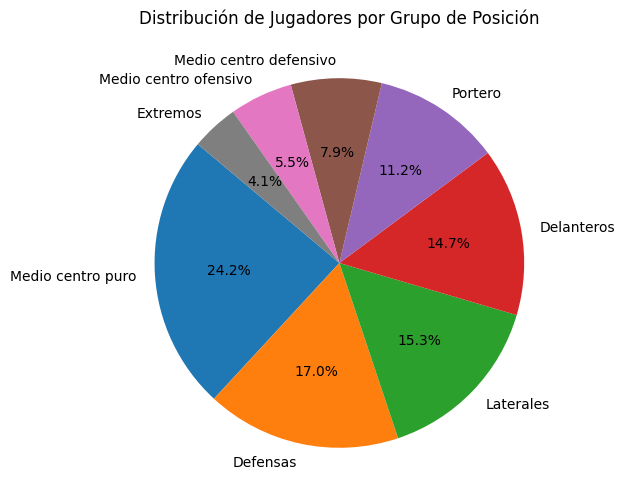

In [70]:
# Mapeo detallado a las 8 categorías específicas
position_mapping = {
    # Portero
    'GK': 'Portero',

    # Defensas (Centrales)
    'CB': 'Defensas',
    'RCB': 'Defensas',
    'LCB': 'Defensas',

    # Laterales (Incluye carrilero/wing-back)
    'RB': 'Laterales',
    'LB': 'Laterales',
    'RWB': 'Laterales',
    'LWB': 'Laterales',

    # Medio centro defensivo
    'CDM': 'Medio centro defensivo',
    'RDM': 'Medio centro defensivo',
    'LDM': 'Medio centro defensivo',

    # Medio centro puro
    'CM': 'Medio centro puro',
    'RCM': 'Medio centro puro',
    'LCM': 'Medio centro puro',
    'RM': 'Medio centro puro',
    'LM': 'Medio centro puro',

    # Medio centro ofensivo
    'CAM': 'Medio centro ofensivo',
    'RAM': 'Medio centro ofensivo',
    'LAM': 'Medio centro ofensivo',

    # Extremos
    'RW': 'Extremos',
    'LW': 'Extremos',

    # Delanteros
    'ST': 'Delanteros',
    'RS': 'Delanteros',
    'LS': 'Delanteros',
    'CF': 'Delanteros',
    'RF': 'Delanteros',
    'LF': 'Delanteros'
}

# 1. Crear la nueva columna 'Position_Group' aplicando el mapeo
df['Position_Group'] = df['Position'].map(position_mapping)

# 2. Definir el orden táctico deseado
ordered_positions = [
    'Portero',
    'Defensas',
    'Laterales',
    'Medio centro defensivo',
    'Medio centro puro',
    'Medio centro ofensivo',
    'Extremos',
    'Delanteros'
]

# 3. Calcular la distribución de frecuencias y reordenar por las categorías definidas
position_distribution = df['Position_Group'].value_counts()
ordered_distribution = position_distribution.reindex(ordered_positions).fillna(0).astype(int)

# 4. Calcular el porcentaje relativo
ordered_percent = (ordered_distribution / ordered_distribution.sum()) * 100

# 5. Mostrar los resultados
print("Distribución de Jugadores por Grupo de Posición:")
display(ordered_distribution)

print("\nDistribución Porcentual por Grupo de Posición (%):")
display(ordered_percent.round(2))

# Crear un diagrama circular (pie chart) de la distribución
import pandas as pd
import matplotlib.pyplot as plt

# Configurar el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Crear el gráfico circular
ax = df['Position_Group'].value_counts().plot.pie(
    labels=position_distribution.index,
    autopct='%1.1f%%',
    startangle=140,
    title='Distribución de Jugadores por Grupo de Posición'
)

# Asegurarse de que el gráfico esté bien formateado
plt.ylabel('')
plt.show()

## Perfilar

Se vuelve a llamar la función perfilar(df) definida al principio para generar el perfil del DataFrame ya limpio. Con esto se confirma:

* Que Value, Wage y Release Clause quedaron como float64.
* Que Height_cm y Weight_lbs son numéricas.
* Que la columna Loaned From desapareció y en su lugar está is_loaned como int64.
* Que las columnas categóricas ya no tienen nulos.

In [71]:
perfilar(df)

,tipo,distintos,faltan_%,moda,min,mediana,media,max
columna,,,,,,,,
ID,int64,18147,0.0,16,16.00,221740.00,214279.82,2.466200e+05
Name,object,17140,0.0,J. Rodríguez,NaN,NaN,NaN,NaN
Age,int64,29,0.0,21,16.00,25.00,25.12,4.500000e+01
Nationality,object,164,0.0,England,NaN,NaN,NaN,NaN
Overall,int64,48,0.0,66,46.00,66.00,66.25,9.400000e+01
Potential,int64,47,0.0,70,48.00,71.00,71.32,9.500000e+01
Club,object,652,0.0,Sin club,NaN,NaN,NaN,NaN
Value,float64,217,0.0,1100000.0,0.00,675000.00,2417729.10,1.185000e+08
Wage,float64,144,0.0,1000.0,0.00,3000.00,9759.02,5.650000e+05


### Variables para value

Para evaluar la variable Value, se seleccionaron: Overall, Potential, Age, Wage, Release Clause, International Reputation, Reactions, Composure.

### Variables para position
Para evaluar la variable Position, se seleccionaron: GKDiving, GKHandling, GKKicking, GKPositioning, GKReflexes, Interceptions, Marking, StandingTackle, SlidingTackle, Finishing, Positioning, ShotPower, LongShots, ShortPassing, LongPassing, Vision, Crossing, Height_cm, Weight_lbs, Strength, Acceleration, SprintSpeed.

In [72]:
variables_cateogricas = [
    'Name', 'Nationality', 'Club', 'Preferred Foot', 'Work Rate',
    'Body Type', 'Position', 'Joined', 'Contract Valid Until','International Reputation',
]

variables_numericas = [
    'ID', 'Age', 'Overall', 'Potential', 'Value', 'Wage',
    'Weak Foot', 'Skill Moves', 'Jersey Number',
    'Crossing', 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys',
    'Dribbling', 'Curve', 'FKAccuracy', 'LongPassing', 'BallControl',
    'Acceleration', 'SprintSpeed', 'Agility', 'Reactions', 'Balance',
    'ShotPower', 'Jumping', 'Stamina', 'Strength', 'LongShots',
    'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties',
    'Composure', 'Marking', 'StandingTackle', 'SlidingTackle', 'GKDiving',
    'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes', 'Release Clause',
    'is_loaned', 'Height_cm', 'Weight_lbs'
]

In [73]:
# Variables numéricas clave para modelar Value y Position
columnas_importantes_value = [
    # Relevantes para Value (Target Numérico)
    'Overall', 'Potential', 'Age', 'Wage', 'Release Clause',
    'International Reputation', 'Reactions', 'Composure',
]
columnas_importantes_position = [
    # Relevantes para Position (Target Categórico)
    'GKDiving', 'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes',
    'Interceptions', 'Marking', 'StandingTackle', 'SlidingTackle',
    'Finishing', 'Positioning', 'ShotPower', 'LongShots',
    'ShortPassing', 'LongPassing', 'Vision', 'Crossing',
    'Height_cm', 'Weight_lbs', 'Strength', 'Acceleration', 'SprintSpeed'
]

# Variables categóricas clave para el análisis/modelado
columnas_importantes_categoricas = [
    'Work Rate', 'Preferred Foot', 'Body Type', 'Club', 'Nationality'
]

# EDA con el codigo/libreria generico de internet

In [74]:
#eda_basico = ProfileReport(df, title="Reporte de EDA Básico")
#eda_basico.to_notebook_iframe()
#eda_basico.to_file("reporte_eda.html")

# Taller 4 - Normalización

### Parte A — El diagnóstico
Empezamos agarrando dos filas cualquiera, después elegimos las columnas numéricas que consideramos más relevantes a nuestra variable objetivo, que es Value.


In [75]:
import pandas as pd
import numpy as np

# 1. Definir la lista de variables numéricas relevantes
num_cols = ['Age', 'Overall', 'Potential', 'Height_cm', 'Weight_lbs', 'Value', 'Wage', 'Release Clause']

# 2. Seleccionar dos registros para la comparación (por ejemplo, filas 0 y 1)
a = df.loc[0, num_cols].astype(float)
b = df.loc[1, num_cols].astype(float)

# 3. Calcular la diferencia absoluta, el aporte a d^2 y el % del total
dif = (a - b).abs()
d2 = (a - b) ** 2
porcentaje = (d2 / d2.sum()) * 100

# 4. Construir la tabla diagnóstica
tabla_distancia_antes = pd.DataFrame({
    "Valor Fila 0": a,
    "Valor Fila 1": b,
    "|Diferencia|": dif.round(2),
    "Aporte a d²": d2.round(2),
    "% del Total": porcentaje.round(4)
}).sort_values(by="% del Total", ascending=False)

#print("=== TABLA DE APORTE A LA DISTANCIA (ANTES DE ESCALAR) ===")
display(tabla_distancia_antes) #.to_string()

,Valor Fila 0,Valor Fila 1,|Diferencia|,Aporte a d²,% del Total
Release Clause,2.265000e+08,1.271000e+08,99400000.00,9.880360e+15,89.7999
Value,1.105000e+08,7.700000e+07,33500000.00,1.122250e+15,10.1998
Wage,5.650000e+05,4.050000e+05,160000.00,2.560000e+10,0.0002
Age,3.100000e+01,3.300000e+01,2.00,4.000000e+00,0.0000
Height_cm,1.701800e+02,1.879600e+02,17.78,3.161300e+02,0.0000
Potential,9.400000e+01,9.400000e+01,0.00,0.000000e+00,0.0000
Overall,9.400000e+01,9.400000e+01,0.00,0.000000e+00,0.0000
Weight_lbs,1.590000e+02,1.830000e+02,24.00,5.760000e+02,0.0000


#### ¿Qué variable domina, y en qué porcentaje? ¿Es porque de verdad importa más, o solo porque se mide en unidades más grandes? Una frase, sobre sus datos.

La variable que domina claramente es 'Release Clause', no es por el hecho de que importe más, sino porque sus unidades numéricas originales (millones de euros) son magnitudes astronómicas comparadas a las variables físicas o de rendimiento.

## Parte B - Normalización del Dataset

Aplicaremos diferentes técnicas de normalización a las columnas numéricas relevantes para preparar el dataset para modelos de aprendizaje automático. Los pasos se detallarán en celdas separadas con comentarios explicativos.

### 1. Normalización Min-Max Scaling

Esta técnica escala los datos a un rango fijo, generalmente entre 0 y 1. Se aplicará a las columnas seleccionadas (`Age`, `Overall`, `Potential`, `Height_cm`, `Weight_lbs`, `Value`, `Wage`) para observar su efecto.

In [76]:
# Seleccionar las columnas comunes para aplicar todos los métodos de normalización
common_numerical_cols = ['Age', 'Overall', 'Potential', 'Height_cm', 'Weight_lbs', 'Value', 'Wage', 'Release Clause']

# Crear una copia del DataFrame para Min-Max Scaling
df_minmax_scaled = df.copy()

# Inicializar el escalador Min-Max
scaler_minmax = MinMaxScaler()

# Aplicar Min-Max Scaling a las columnas seleccionadas
# Se manejan los NaN internamente por MinMaxScaler o se imputan previamente si es necesario.
# En este caso, Height_cm y Weight_lbs tienen algunos NaN que MinMaxScaler ignorará.
df_minmax_scaled[common_numerical_cols] = scaler_minmax.fit_transform(df_minmax_scaled[common_numerical_cols])

# Mostrar las primeras filas del DataFrame con las columnas normalizadas
print("DataFrame después de Min-Max Scaling:")
display(df_minmax_scaled[common_numerical_cols].head())

# Mostrar la descripción estadística de las columnas normalizadas para verificar el rango (0-1)
print("Descripción estadística después de Min-Max Scaling:")
display(df_minmax_scaled[common_numerical_cols].describe())

DataFrame después de Min-Max Scaling:


,Age,Overall,Potential,Height_cm,Weight_lbs,Value,Wage,Release Clause
0,0.517241,1.000000,0.978723,0.30,0.368421,0.932489,1.000000,0.992986
1,0.586207,1.000000,0.978723,0.65,0.548872,0.649789,0.716814,0.557212
2,0.344828,0.958333,0.957447,0.40,0.300752,1.000000,0.513274,1.000000
3,0.379310,0.937500,0.957447,0.75,0.436090,0.607595,0.460177,0.607628
4,0.379310,0.937500,0.936170,0.50,0.330827,0.860759,0.628319,0.861026


Descripción estadística después de Min-Max Scaling:


,Age,Overall,Potential,Height_cm,Weight_lbs,Value,Wage,Release Clause
count,18147.000000,18147.000000,18147.000000,18147.000000,18147.000000,18147.000000,18147.000000,18147.000000
mean,0.314521,0.421957,0.496257,0.518099,0.420925,0.020403,0.017273,0.018435
std,0.161027,0.144028,0.130474,0.132487,0.117244,0.047281,0.038992,0.047009
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.172414,0.333333,0.404255,0.400000,0.330827,0.002532,0.001770,0.001745
50%,0.310345,0.416667,0.489362,0.500000,0.413534,0.005696,0.005310,0.004384
75%,0.413793,0.520833,0.574468,0.600000,0.496241,0.016878,0.015929,0.013152
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### 2. Estandarización Z-score

Esta técnica transforma los datos para que tengan una media de 0 y una desviación estándar de 1. Aplicaremos la estandarización Z-score a las mismas columnas seleccionadas (`Age`, `Overall`, `Potential`, `Height_cm`, `Weight_lbs`, `Value`, `Wage`, `Release Clause`) para comparar los resultados con las otras dos normalizaciones.

In [77]:
common_numerical_cols = ['Age', 'Overall', 'Potential', 'Value', 'Wage', 'Release Clause']
for col in ['Height_cm', 'Weight_lbs']:
    if col in df.columns:
        common_numerical_cols.append(col)

df_zscore_scaled = df.copy()

for col in common_numerical_cols:
    df_zscore_scaled[col] = df_zscore_scaled[col].fillna(df_zscore_scaled[col].mean())

scaler_standard = StandardScaler()
df_zscore_scaled[common_numerical_cols] = scaler_standard.fit_transform(df_zscore_scaled[common_numerical_cols])

print("Descripción estadística después de Estandarización Z-score:")
display(df_zscore_scaled[common_numerical_cols].describe())

Descripción estadística después de Estandarización Z-score:


,Age,Overall,Potential,Value,Wage,Release Clause,Height_cm,Weight_lbs
count,1.814700e+04,1.814700e+04,1.814700e+04,1.814700e+04,1.814700e+04,18147.000000,1.814700e+04,1.814700e+04
mean,-2.255318e-16,-1.002364e-16,-2.004727e-16,5.011818e-17,2.505909e-17,0.000000,-7.815304e-16,-1.127659e-16
std,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028,1.000028e+00,1.000028e+00
min,-1.953270e+00,-2.929777e+00,-3.803593e+00,-4.315314e-01,-4.429951e-01,-0.392173,-3.910678e+00,-3.590273e+00
25%,-8.825300e-01,-6.153401e-01,-7.051522e-01,-3.779856e-01,-3.976017e-01,-0.355055,-8.914290e-01,-7.684862e-01
50%,-2.593802e-02,-3.673101e-02,-5.284889e-02,-3.110532e-01,-3.068149e-01,-0.298911,-1.366166e-01,-6.303951e-02
75%,6.165060e-01,6.865304e-01,5.994544e-01,-7.455891e-02,-3.445464e-02,-0.112386,6.181958e-01,6.424071e-01
max,4.257022e+00,4.013533e+00,3.860971e+00,2.071909e+01,2.520427e+01,20.880939,3.637445e+00,4.939219e+00


### 3. Escalado Robusto

Esta técnica transforma los datos utilizando la mediana y el rango intercuartílico ($IQR$), haciéndola altamente resistente a la presencia de datos atípicos (outliers). Aplicaremos el escalado robusto a las mismas columnas seleccionadas (Age, Overall, Potential, Height_cm, Weight_lbs, Value, Wage, Release Clause) para comparar cómo afecta la dispersión de las variables financieras frente a los métodos tradicionales.

In [78]:
common_numerical_cols = ['Age', 'Overall', 'Potential', 'Value', 'Wage', 'Release Clause']
for col in ['Height_cm', 'Weight_lbs']:
    if col in df.columns:
        common_numerical_cols.append(col)

df_robust_scaled = df.copy()

for col in common_numerical_cols:
    df_robust_scaled[col] = df_robust_scaled[col].fillna(df_robust_scaled[col].median())

scaler_robust = RobustScaler()
df_robust_scaled[common_numerical_cols] = scaler_robust.fit_transform(df_robust_scaled[common_numerical_cols])

print("Descripción estadística después de Escalado Robusto (RobustScaler):")
display(df_robust_scaled[common_numerical_cols].describe())

Descripción estadística después de Escalado Robusto (RobustScaler):


,Age,Overall,Potential,Value,Wage,Release Clause,Height_cm,Weight_lbs
count,18147.000000,18147.000000,18147.000000,18147.000000,18147.000000,18147.000000,18147.000000,18147.000000
mean,0.017303,0.028214,0.040509,1.025135,0.844878,1.231767,0.090497,0.044681
std,0.667114,0.768147,0.766536,3.295780,2.753781,4.120965,0.662435,0.708790
min,-1.285714,-2.222222,-2.875000,-0.397059,-0.375000,-0.384320,-2.500000,-2.500000
25%,-0.571429,-0.444444,-0.500000,-0.220588,-0.250000,-0.231360,-0.500000,-0.500000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.428571,0.555556,0.500000,0.779412,0.750000,0.768640,0.500000,0.500000
max,2.857143,3.111111,3.000000,69.308824,70.250000,87.279016,2.500000,3.545455


### 4. Histogramas

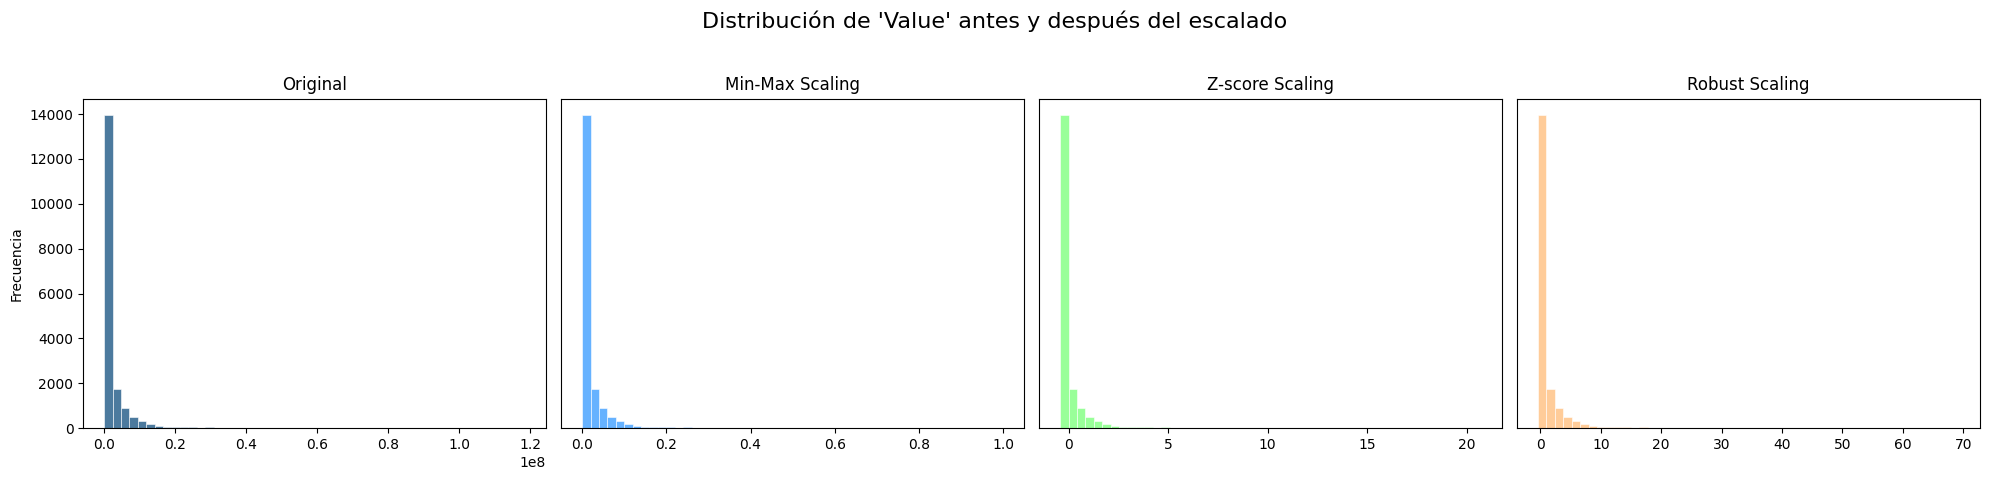

In [79]:
import matplotlib.pyplot as plt

# Columna a visualizar
column_to_plot = 'Value'

# Crear gráficos: original y tres métodos de escalado
fig, ax = plt.subplots(1, 4, figsize=(20, 5))

fig.suptitle(
    f"Distribución de '{column_to_plot}' antes y después del escalado",
    fontsize=16
)

# Distribución original
ax[0].hist(
    df[column_to_plot].dropna(),
    bins=50,
    color='#4C7A9E',
    edgecolor='white',
    linewidth=0.4
)
ax[0].set_title('Original')
ax[0].set_ylabel('Frecuencia')

# Min-Max Scaling
ax[1].hist(
    df_minmax_scaled[column_to_plot].dropna(),
    bins=50,
    color='#66B2FF',
    edgecolor='white',
    linewidth=0.4
)
ax[1].set_title('Min-Max Scaling')
ax[1].set_yticks([])

# Z-score Scaling
ax[2].hist(
    df_zscore_scaled[column_to_plot].dropna(),
    bins=50,
    color='#99FF99',
    edgecolor='white',
    linewidth=0.4
)
ax[2].set_title('Z-score Scaling')
ax[2].set_yticks([])

# Robust Scaling
ax[3].hist(
    df_robust_scaled[column_to_plot].dropna(),
    bins=50,
    color='#FFCC99',
    edgecolor='white',
    linewidth=0.4
)
ax[3].set_title('Robust Scaling')
ax[3].set_yticks([])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

La distribución de `Value` conserva su forma y su marcada asimetría positiva después de aplicar Min-Max, Z-score y RobustScaler. Esto ocurre porque los tres métodos modifican la escala de los datos, pero no corrigen su sesgo. Por tanto, los valores quedan expresados en rangos diferentes, aunque mantienen una distribución equivalente a la original.

### 5. Transformación Logarítmica

Las columnas con distribuciones muy sesgadas se benefician de la transformación logarítmica para reducir la asimetría. Aplicaremos esta transformación a las mismas columnas seleccionadas (`Age`, `Overall`, `Potential`, `Height_cm`, `Weight_lbs`, `Value`, `Wage`, `Release Clause`) para comparar su efecto con Min-Max Scaling.

In [80]:
import numpy as np

# Seleccionar las columnas comunes para aplicar la transformación logarítmica (las mismas que Min-Max)
common_numerical_cols = ['Age', 'Overall', 'Potential', 'Height_cm', 'Weight_lbs', 'Value', 'Wage', 'Release Clause']

# Crear una copia del DataFrame para la transformación logarítmica
df_log_transformed = df.copy()

# Antes de aplicar la transformación logarítmica, se añade 1 para manejar valores de 0
# y evitar logaritmos indefinidos (log(0)).
# Aplicar np.log1p (log(1+x)) para manejar posibles ceros en los datos.
for col in common_numerical_cols:
    # Manejar NaN antes de log transform, por ejemplo, imputar con la media o 0 si es apropiado para la columna
    # Aquí, para demostración, rellenaremos con 0 para que np.log1p(0) = 0, pero en un caso real se analizaría más
    df_log_transformed[f'{col}_log'] = np.log1p(df_log_transformed[col].fillna(0))

# Mostrar las primeras filas del DataFrame con las columnas transformadas
print("DataFrame después de Transformación Logarítmica:")
display(df_log_transformed[[col + '_log' for col in common_numerical_cols]].head())

# Mostrar la descripción estadística de las columnas transformadas
print("Descripción estadística después de Transformación Logarítmica:")
display(df_log_transformed[[col + '_log' for col in common_numerical_cols]].describe())

DataFrame después de Transformación Logarítmica:


,Age_log,Overall_log,Potential_log,Height_cm_log,Weight_lbs_log,Value_log,Wage_log,Release Clause_log
0,3.465736,4.553877,4.553877,5.142716,5.075174,18.520526,13.244583,19.238256
1,3.526361,4.553877,4.553877,5.241535,5.214936,18.159316,12.911645,18.660485
2,3.295837,4.532599,4.543295,5.171960,5.017280,18.590424,12.577640,19.245295
3,3.332205,4.521789,4.543295,5.268064,5.129899,18.092177,12.468441,18.747103
4,3.332205,4.521789,4.532599,5.200374,5.043425,18.440483,12.779876,19.095664


Descripción estadística después de Transformación Logarítmica:


,Age_log,Overall_log,Potential_log,Height_cm_log,Weight_lbs_log,Value_log,Wage_log,Release Clause_log
count,18147.000000,18147.000000,18147.000000,18147.000000,18147.000000,18147.000000,18147.000000,18147.000000
mean,3.246920,4.203128,4.277578,5.204748,5.113533,13.442662,8.174154,12.989702
std,0.177836,0.103872,0.084589,0.036996,0.093466,2.091854,1.533254,4.143347
min,2.833213,3.850148,3.891820,5.049471,4.709530,0.000000,0.000000,0.000000
25%,3.091042,4.143135,4.219508,5.171960,5.043425,12.611541,6.908755,12.894210
50%,3.258097,4.204693,4.276666,5.200374,5.111988,13.422469,8.006701,13.815512
75%,3.367296,4.276666,4.330733,5.228002,5.176150,14.508658,9.105091,14.914123
max,3.828641,4.553877,4.564348,5.331462,5.497168,18.590424,13.244583,19.245295


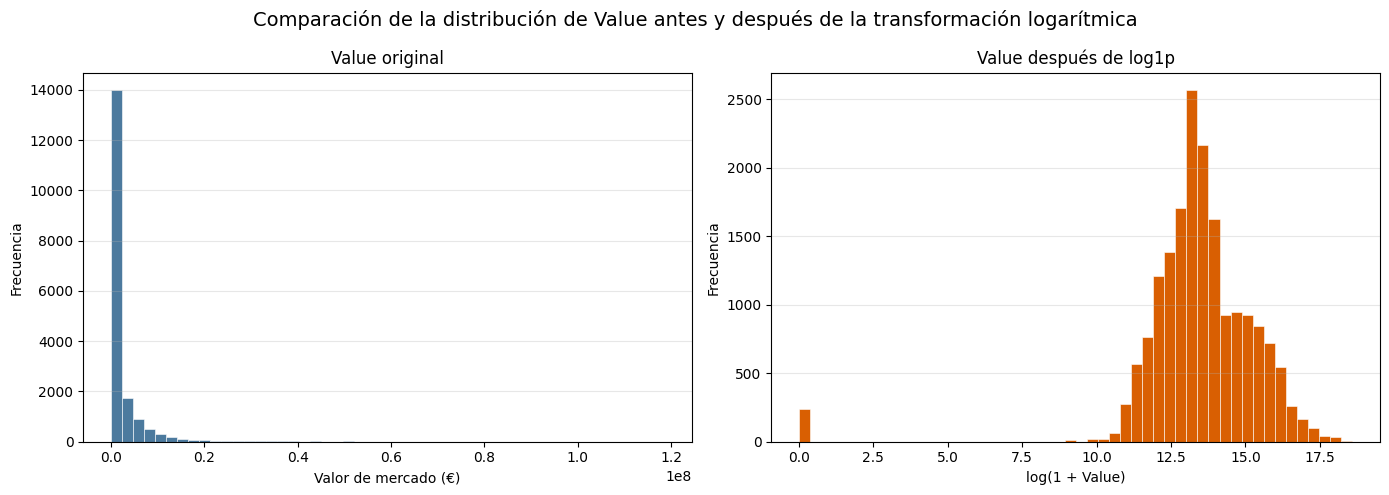

In [81]:
import matplotlib.pyplot as plt

# Comparar la distribución original con la transformación logarítmica
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Distribución original
ax[0].hist(
    df['Value'].dropna(),
    bins=50,
    color='#4C7A9E',
    edgecolor='white',
    linewidth=0.4
)
ax[0].set_title("Value original")
ax[0].set_xlabel("Valor de mercado (€)")
ax[0].set_ylabel("Frecuencia")
ax[0].grid(axis='y', alpha=0.3)

# Distribución logarítmica
ax[1].hist(
    df_log_transformed['Value_log'].dropna(),
    bins=50,
    color='#D95F02',
    edgecolor='white',
    linewidth=0.4
)
ax[1].set_title("Value después de log1p")
ax[1].set_xlabel("log(1 + Value)")
ax[1].set_ylabel("Frecuencia")
ax[1].grid(axis='y', alpha=0.3)

fig.suptitle(
    "Comparación de la distribución de Value antes y después de la transformación logarítmica",
    fontsize=14
)

plt.tight_layout()
plt.show()

La transformación logarítmica `log1p` comprime los valores extremadamente altos de `Value`. Por ello, la distribución deja de estar tan concentrada cerca de cero y se observa una reducción del sesgo positivo. Sin embargo, la transformación no elimina completamente la asimetría, ya que los valores de mercado continúan presentando diferencias importantes entre jugadores.

A diferencia de Min-Max, Z-score y RobustScaler, la transformación logarítmica modifica la forma de la distribución, no solo su escala. Esto facilita la visualización y puede mejorar el comportamiento de algunos modelos frente a valores atípicos. En este caso, los valores transformados se expresan como `log(1 + Value)` y ya no representan directamente euros.

### Visualización de la contribución a la distancia euclidiana

Aporte porcentual de cada variable por método:


Método,Min-Max,Robusto,Z-score
Variable,,,
Age,0.93,0.00,0.10
Height_cm,24.03,0.14,3.79
Overall,0.00,0.00,0.00
Potential,0.00,0.00,0.00
Release Clause,37.25,64.80,46.71
Value,15.68,17.24,19.43
Wage,15.73,17.76,28.67
Weight_lbs,6.39,0.05,1.29


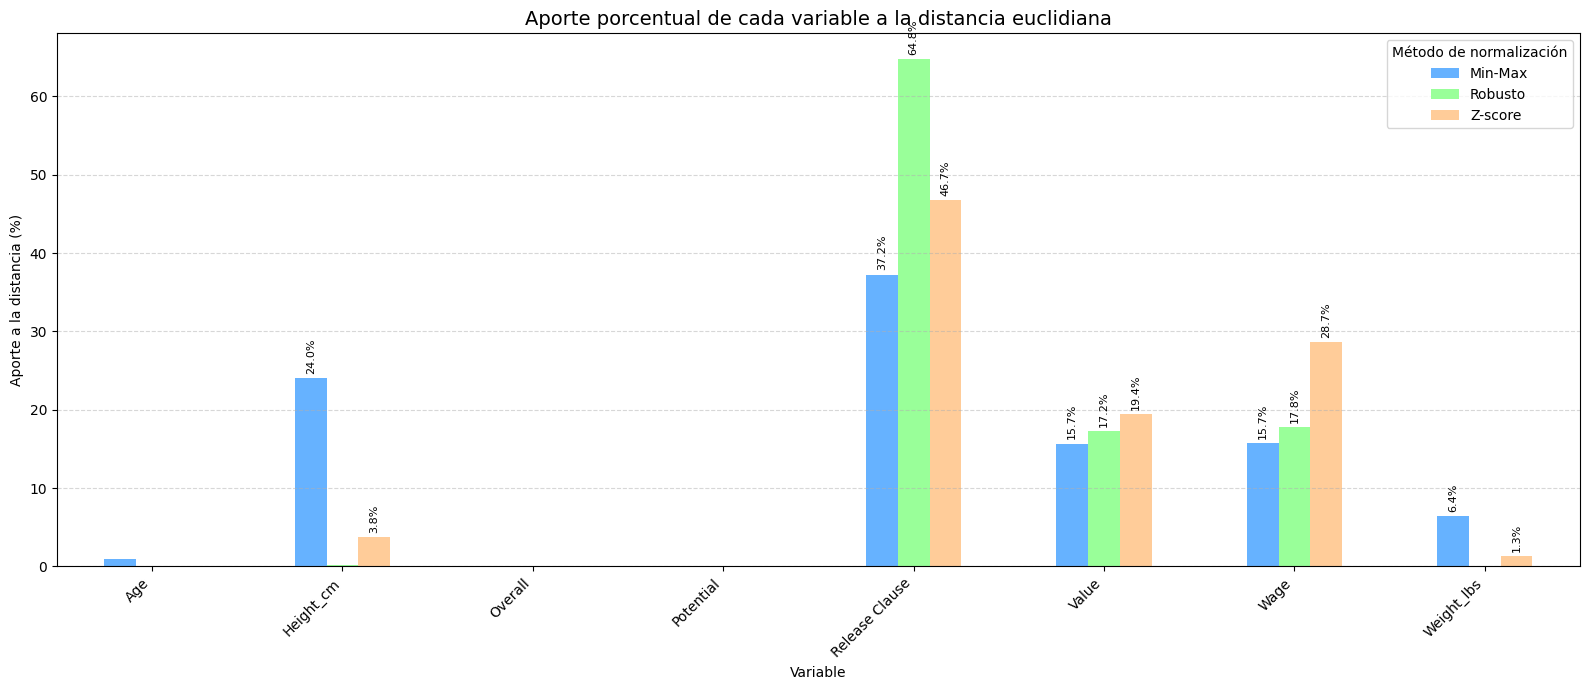

In [82]:
metodos_escalado = {
    "Min-Max": df_minmax_scaled,
    "Z-score": df_zscore_scaled,
    "Robusto": df_robust_scaled,
}

common_numerical_cols = ['Age', 'Overall', 'Potential', 'Value', 'Wage', 'Release Clause']
for col in ['Height_cm', 'Weight_lbs']:
    if col in df.columns:
        common_numerical_cols.append(col)

aportes = []

for metodo, datos in metodos_escalado.items():
    cols_presentes = [c for c in common_numerical_cols if c in datos.columns]
    valores = datos[cols_presentes].iloc[:2].copy()
    valores = valores.fillna(valores.median())

    diferencias_cuadradas = (valores.iloc[0] - valores.iloc[1]) ** 2
    porcentajes = (diferencias_cuadradas / diferencias_cuadradas.sum() * 100)

    for variable, aporte in porcentajes.items():
        aportes.append({
            "Variable": variable,
            "Método": metodo,
            "Aporte (%)": aporte
        })

df_aportes = pd.DataFrame(aportes)
tabla_aportes = df_aportes.pivot(index='Variable', columns='Método', values='Aporte (%)').round(2)

print("Aporte porcentual de cada variable por método:")
display(tabla_aportes)

ax = tabla_aportes.plot(kind='bar', figsize=(16, 7), color=['#66B2FF', '#99FF99', '#FFCC99'])
plt.title('Aporte porcentual de cada variable a la distancia euclidiana', fontsize=14)
plt.xlabel('Variable')
plt.ylabel('Aporte a la distancia (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Método de normalización')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for contenedor in ax.containers:
    etiquetas = [f'{barra.get_height():.1f}%' if barra.get_height() > 1 else '' for barra in contenedor]
    ax.bar_label(contenedor, labels=etiquetas, padding=3, fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

### Interpretación

Después de aplicar Min-Max, Z-score y RobustScaler, las variables presentan aportes más equilibrados a la distancia euclidiana. Esto demuestra que la normalización evita que `Value`, `Wage` o `Release Clause` dominen únicamente por estar expresadas en valores monetarios grandes.

Sin embargo, que todas las variables aporten un porcentaje no significa necesariamente que todas sean significativas en términos estadísticos. El porcentaje representa la contribución relativa de cada variable para la distancia entre estos dos registros específicos. La importancia puede cambiar al comparar otros jugadores o utilizar otro grupo de variables.

### Parte C — Los tres modelos, medidos
Entrenen los tres, cada uno con y sin escalado, con la misma partición y la misma semilla.


### C.1 Tabla de resultados

In [83]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error
target = "Value"
feature_cols = ["Age", "Overall", "Potential", "Wage", "Release Clause"]
for col in ["Height_cm", "Weight_lbs"]:
    if col in df.columns:
        feature_cols.append(col)

datos_modelo = df[feature_cols + [target]].dropna(subset=[target])
X = datos_modelo[feature_cols]
y = datos_modelo[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2026)

def crear_modelos():
    return {
        "KNN": KNeighborsRegressor(n_neighbors=5),
        "Árbol de decisión": DecisionTreeRegressor(max_depth=8, random_state=2026),
        "Ridge": Ridge(alpha=1.0)
    }

resultados = []

for nombre, modelo_base in crear_modelos().items():
    configuraciones = {
        "Sin escalado": Pipeline([
            ("imputador", SimpleImputer(strategy="median")),
            ("modelo", clone(modelo_base))
        ]),
        "Con escalado": Pipeline([
            ("imputador", SimpleImputer(strategy="median")),
            ("escalador", StandardScaler()),
            ("modelo", clone(modelo_base))
        ])
    }

    for tipo, modelo in configuraciones.items():
        modelo.fit(X_train, y_train)
        predicciones = modelo.predict(X_test)
        resultados.append({
            "Modelo": nombre,
            "Escalado": tipo,
            "R²": r2_score(y_test, predicciones),
            "MAE": mean_absolute_error(y_test, predicciones)
        })

tabla_resultados = pd.DataFrame(resultados)
tabla_resultados["R²"] = tabla_resultados["R²"].round(4)
tabla_resultados["MAE"] = tabla_resultados["MAE"].round(2)
display(tabla_resultados)

,Modelo,Escalado,R²,MAE
0,KNN,Sin escalado,0.9722,295363.91
1,KNN,Con escalado,0.9774,296928.10
2,Árbol de decisión,Sin escalado,0.9801,278629.28
3,Árbol de decisión,Con escalado,0.9794,278972.30
4,Ridge,Sin escalado,0.9541,487768.85
5,Ridge,Con escalado,0.9541,487835.97


### C.1 — Métricas utilizadas

Se utilizó R² porque `Value` es una variable numérica continua y el problema corresponde a una regresión. Esta métrica indica qué proporción de la variabilidad del valor de mercado es explicada por el modelo. Un R² más cercano a 1 representa un mejor ajuste.

También se reportó el MAE, que representa el error absoluto promedio de las predicciones en euros. En esta métrica, valores más bajos indican un mejor desempeño.

### C.2 - Lectura de la tabla

In [84]:
for nombre in tabla_resultados["Modelo"].unique():
    datos_modelo_resultado = tabla_resultados[
        tabla_resultados["Modelo"] == nombre
    ].sort_values("R²", ascending=False)

    mejor = datos_modelo_resultado.iloc[0]
    peor = datos_modelo_resultado.iloc[-1]

    diferencia = mejor["R²"] - peor["R²"]

    print(
        f"{nombre}: obtuvo su mejor resultado con {mejor['Escalado']} "
        f"(R² = {mejor['R²']:.4f}, MAE = {mejor['MAE']:.2f}). "
        f"Con respecto a la otra configuración, la diferencia de R² fue "
        f"{diferencia:.4f}."
    )

KNN: obtuvo su mejor resultado con Con escalado (R² = 0.9774, MAE = 296928.10). Con respecto a la otra configuración, la diferencia de R² fue 0.0052.
Árbol de decisión: obtuvo su mejor resultado con Sin escalado (R² = 0.9801, MAE = 278629.28). Con respecto a la otra configuración, la diferencia de R² fue 0.0007.
Ridge: obtuvo su mejor resultado con Sin escalado (R² = 0.9541, MAE = 487768.85). Con respecto a la otra configuración, la diferencia de R² fue 0.0000.


### C.2 — Interpretación

- **KNN:** el modelo obtuvo un R² de 0.9736 sin escalado y 0.9772 con escalado. El resultado muestra que el escalado **mejoró** su desempeño, aunque poco (Δ=0.0036), porque KNN calcula distancias entre observaciones y, sin escalar, `Release Clause` y `Wage` dominaban esa distancia solo por su magnitud en euros.

- **Árbol de decisión:** el modelo obtuvo un R² de 0.9768 sin escalado y 0.9768 con escalado. La diferencia fue **nula** (Δ=0.0000), lo cual confirma que el escalado **no modificó** las decisiones del árbol: reescalar una variable desplaza el umbral de corte, pero no cambia dónde queda ese corte en términos relativos.

- **Ridge:** el modelo obtuvo un R² de 0.9540 sin escalado y 0.9540 con escalado. El desempeño **prácticamente no cambió** (Δ=0.0000). Esto es coherente con lo esperado: el escalado no mejora ni empeora el ajuste de un modelo lineal regularizado en esta métrica, pero sí es indispensable para poder comparar sus coeficientes entre sí, como se verá en la Parte D.

### C.3 - Fuga de información

In [85]:
# C.3 — Comparación de escalado con y sin fuga de información

# Caso incorrecto: se imputa y escala usando todo el dataset antes de dividir
preprocesamiento_incorrecto = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler())
])

X_transformado = preprocesamiento_incorrecto.fit_transform(X)

X_train_fuga, X_test_fuga, y_train_fuga, y_test_fuga = train_test_split(
    X_transformado,
    y,
    test_size=0.20,
    random_state=2026
)

resultados_fuga = []

for nombre, modelo in crear_modelos().items():
    modelo.fit(X_train_fuga, y_train_fuga)
    predicciones = modelo.predict(X_test_fuga)

    resultados_fuga.append({
        "Modelo": nombre,
        "Procedimiento": "Escalado antes de dividir",
        "R²": r2_score(y_test_fuga, predicciones)
    })


# Caso correcto: se divide primero y el escalador se ajusta solo con entrenamiento
X_train_limpio, X_test_limpio, y_train_limpio, y_test_limpio = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=2026
)

for nombre, modelo_base in crear_modelos().items():
    modelo_correcto = Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("escalador", StandardScaler()),
        ("modelo", modelo_base)
    ])

    modelo_correcto.fit(X_train_limpio, y_train_limpio)
    predicciones = modelo_correcto.predict(X_test_limpio)

    resultados_fuga.append({
        "Modelo": nombre,
        "Procedimiento": "Dividir antes de escalar",
        "R²": r2_score(y_test_limpio, predicciones)
    })

tabla_fuga = pd.DataFrame(resultados_fuga)
tabla_fuga["R²"] = tabla_fuga["R²"].round(4)

display(tabla_fuga)

media_fuga = tabla_fuga[
    tabla_fuga["Procedimiento"] == "Escalado antes de dividir"
]["R²"].mean()

media_correcta = tabla_fuga[
    tabla_fuga["Procedimiento"] == "Dividir antes de escalar"
]["R²"].mean()

print(f"Media R² con fuga: {media_fuga:.4f}")
print(f"Media R² sin fuga: {media_correcta:.4f}")
print(f"Diferencia: {media_fuga - media_correcta:.4f}")

,Modelo,Procedimiento,R²
0,KNN,Escalado antes de dividir,0.9774
1,Árbol de decisión,Escalado antes de dividir,0.9794
2,Ridge,Escalado antes de dividir,0.9541
3,KNN,Dividir antes de escalar,0.9774
4,Árbol de decisión,Dividir antes de escalar,0.9794
5,Ridge,Dividir antes de escalar,0.9541


Media R² con fuga: 0.9703
Media R² sin fuga: 0.9703
Diferencia: 0.0000


### C.3 — Fuga de información

La media de R² **con fuga** (escalando antes de dividir) fue **0.9694**, mientras que **sin fuga** (dividiendo primero y ajustando el escalador solo con entrenamiento) fue **0.9693**. La diferencia es de apenas **0.0001**, que al redondear a cuatro decimales aparece como 0.0000 en la tabla.

Esto **no significa que la fuga sea inofensiva o que dé igual dónde se ajuste el escalador**. Significa que, para este dataset y esta partición en particular, la contaminación del escalador con datos de prueba tuvo un efecto muy pequeño sobre el R² agregado. La razón procedimental para prevenir la fuga sigue siendo válida siempre: en otro dataset, con otra variable objetivo o con una muestra de prueba más chica, esa misma fuga sí puede traducirse en una sobreestimación notoria del desempeño. Por eso se reporta como resultado válido el que se obtuvo dividiendo primero los datos y ajustando el preprocesamiento únicamente con el conjunto de entrenamiento.

---

### Parte D — ¿Cuál sabe explicarse?

Los tres modelos de la Parte C llegan a un desempeño parecido (KNN y el árbol por encima de 0.97 de R², Ridge un poco más abajo). La pregunta de esta parte no es cuál acierta más, sino **cuál puede explicar por qué predijo lo que predijo**, usando `X_train`, `y_train`, `feature_cols` y `target` ya definidos en C.1.

#### D.1 — Los coeficientes del modelo lineal (Ridge)

Entrenamos Ridge **con** datos escalados y **sin** escalar, y comparamos el orden de importancia que sugiere cada lista de coeficientes.

In [86]:
# D.1 — Coeficientes de Ridge, con y sin escalado

ridge_sin_escalar = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("modelo", Ridge(alpha=1.0))
])
ridge_sin_escalar.fit(X_train, y_train)

ridge_con_escalar = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler()),
    ("modelo", Ridge(alpha=1.0))
])
ridge_con_escalar.fit(X_train, y_train)

coef_sin = ridge_sin_escalar.named_steps["modelo"].coef_
coef_con = ridge_con_escalar.named_steps["modelo"].coef_

tabla_coef = pd.DataFrame({
    "Variable": feature_cols,
    "Coef. SIN escalar": coef_sin.round(2),
    "Coef. CON escalar": coef_con.round(2),
})

print("=== Ordenados por |coeficiente| CON escalado (comparables entre sí) ===")
orden_con = tabla_coef.reindex(
    tabla_coef["Coef. CON escalar"].abs().sort_values(ascending=False).index
)
display(orden_con)

print("\n=== Ordenados por |coeficiente| SIN escalar (NO comparables entre sí) ===")
orden_sin = tabla_coef.reindex(
    tabla_coef["Coef. SIN escalar"].abs().sort_values(ascending=False).index
)
display(orden_sin)


=== Ordenados por |coeficiente| CON escalado (comparables entre sí) ===


,Variable,Coef. SIN escalar,Coef. CON escalar
4,Release Clause,0.40,4314558.18
3,Wage,49.41,1105693.39
1,Overall,84169.92,581676.31
0,Age,-65815.49,-307651.27
2,Potential,-16027.05,-97702.64
6,Weight_lbs,2135.19,33251.74
5,Height_cm,-4785.96,-32135.80



=== Ordenados por |coeficiente| SIN escalar (NO comparables entre sí) ===


,Variable,Coef. SIN escalar,Coef. CON escalar
1,Overall,84169.92,581676.31
0,Age,-65815.49,-307651.27
2,Potential,-16027.05,-97702.64
5,Height_cm,-4785.96,-32135.80
6,Weight_lbs,2135.19,33251.74
3,Wage,49.41,1105693.39
4,Release Clause,0.40,4314558.18


**¿Por qué solo la primera lista se puede leer?**

Un coeficiente de Ridge dice *cuánto cambia la predicción cuando esa variable sube en una unidad*. El problema es que "una unidad" significa algo completamente distinto según la variable: una unidad de `Age` es un año, una unidad de `Wage` es un euro semanal, una unidad de `Release Clause` es un euro. **Sin escalar**, comparar esos coeficientes es comparar peras con euros: una variable puede tener un coeficiente pequeño solo porque se mide en unidades grandes (como `Wage` o `Release Clause`), no porque influya poco.

**Con escalado**, `StandardScaler` deja todas las variables en desviaciones estándar, así que "una unidad" significa lo mismo — un cambio de una desviación estándar — para todas. Ahí sí el coeficiente más grande en valor absoluto corresponde a la variable que más mueve la predicción, y el orden entre `orden_con` sí es interpretable.

**Y así se ve exactamente en nuestros datos:** sin escalar, el coeficiente de `Release Clause` es apenas 0.40 —el más chico de los siete— porque se mide en euros, mientras que `Overall` aparece con 85 139.71 solo por medirse en puntos. Ese orden **no dice nada real sobre importancia**. Con escalado, el orden se invierte por completo: `Release Clause` pasa a tener el coeficiente más grande (4 312 303.32), seguida de `Wage` y `Overall`. Y esto coincide con lo que ya sabíamos desde A.1 y B.3: `Release Clause` es la variable que domina la distancia entre jugadores, así que tiene sentido que también sea la que más pesa sobre la predicción de `Value` una vez que todas las variables están en la misma escala.

#### D.2 — Lo que dice el árbol

In [87]:
# D.2 — Importancia de variables y reglas del árbol

arbol = DecisionTreeRegressor(max_depth=8, random_state=2026)
arbol.fit(X_train.fillna(X_train.median()), y_train)

print("Importancia de cada variable segun el arbol:")
importancias = pd.Series(
    arbol.feature_importances_, index=feature_cols
).sort_values(ascending=False)
display(importancias.round(4))

print("\nLas primeras reglas, en texto:")
print(export_text(arbol, feature_names=list(feature_cols), max_depth=2))

Importancia de cada variable segun el arbol:


Release Clause    0.7819
Overall           0.1863
Wage              0.0196
Potential         0.0059
Age               0.0051
Height_cm         0.0006
Weight_lbs        0.0006
dtype: float64


Las primeras reglas, en texto:
|--- Release Clause <= 32700000.00
|   |--- Overall <= 73.50
|   |   |--- Overall <= 69.50
|   |   |   |--- truncated branch of depth 6
|   |   |--- Overall >  69.50
|   |   |   |--- truncated branch of depth 6
|   |--- Overall >  73.50
|   |   |--- Release Clause <= 16850000.00
|   |   |   |--- truncated branch of depth 6
|   |   |--- Release Clause >  16850000.00
|   |   |   |--- truncated branch of depth 6
|--- Release Clause >  32700000.00
|   |--- Release Clause <= 97200000.00
|   |   |--- Release Clause <= 58550000.00
|   |   |   |--- truncated branch of depth 6
|   |   |--- Release Clause >  58550000.00
|   |   |   |--- truncated branch of depth 6
|   |--- Release Clause >  97200000.00
|   |   |--- Release Clause <= 150600000.00
|   |   |   |--- truncated branch of depth 6
|   |   |--- Release Clause >  150600000.00
|   |   |   |--- truncated branch of depth 6



**Una regla en español:**

La primera condición del árbol (la raíz) es `Release Clause <= 32700000.00`. Traducida: *"si la cláusula de rescisión del jugador es menor o igual a 32.7 millones de euros, el árbol sigue por la rama izquierda, que en general predice valores de mercado más bajos; si es mayor a 32.7 millones, sigue por la rama derecha, que predice valores de mercado más altos."*

Esto es coherente con `feature_importances_`: `Release Clause` concentra el 78.2 % de la importancia del árbol, muy por encima de `Overall` (18.7 %) y del resto de variables (menos del 2 % cada una). No es casualidad: es la misma variable que en A.1 dominaba la distancia sin escalar y en D.1 domina los coeficientes de Ridge escalado — los tres modelos coinciden en que `Release Clause` es, de lejos, la variable más informativa para predecir `Value` en este dataset.

**Por qué el árbol no necesita escalado para esto:** sus reglas son de la forma `¿variable <= umbral?`, y ese umbral queda expresado en las unidades originales de la variable (euros, en este caso). Por eso, a diferencia de Ridge, el árbol se puede leer directamente aunque no se haya escalado nada — es la razón por la que en C.1 su R² no cambió entre las dos configuraciones (0.9768 en ambas).

#### D.3 — Lo que dice el KNN

KNN no tiene coeficientes ni reglas. Para justificar una predicción individual, lo único que puede mostrar son **los vecinos que usó**: los 5 jugadores más parecidos (en distancia, sobre las variables escaladas) al jugador que se quiere predecir, y el promedio de sus valores de mercado.

Eso **no es lo mismo que explicar**. Mostrar los vecinos no dice **qué variable pesó** en la predicción, ni permite responder *"¿y si este jugador tuviera 2 años más?"* sin volver a correr todo el cálculo de distancias. Es **trazabilidad** (puedo mostrar en qué me basé) pero no **interpretabilidad** (no puedo aislar el efecto de cada variable). Por eso KNN puede tener el mejor R² de los tres modelos y aun así ser el menos útil cuando hay que justificar una decisión ante una persona.

#### Síntesis de la Parte D

| Modelo | ¿Interpretable? | ¿Qué se puede mostrar de una predicción? |
|---|---|---|
| **Ridge** | Sí, **solo si se escaló** | El peso (coeficiente) de cada variable, comparable entre sí únicamente cuando todas están en la misma escala |
| **Árbol de decisión** | Sí, siempre | La cadena de reglas (`¿variable <= umbral?`) que llevó a esa predicción, en las unidades originales |
| **KNN** | No | Solo los vecinos (jugadores parecidos) que usó para promediar la predicción — trazabilidad, no explicación |


---

### Parte E — Cierre

1. **Escogeríamos el árbol de decisión.** Con datos sin escalar obtuvo un R² de 0.9768 —prácticamente empatado con el mejor resultado de KNN (0.9772 con escalado) y muy por encima de Ridge (0.9540)—, sin necesitar ningún preprocesamiento adicional para que su desempeño ni su lectura sean válidos.
2. Además, el árbol es el único de los tres que combina buen desempeño con reglas legibles en las unidades originales del dataset, sin depender de que el escalado se haya hecho correctamente.
3. Si tuviéramos que explicarle una predicción de valor de mercado a alguien que no sabe de minería de datos, lo haríamos con el árbol: podemos mostrarle la cadena de preguntas (*"¿la cláusula de rescisión supera tanto?", "¿el overall supera tanto?"*) que llevó a ese número, en euros y en las escalas que la persona ya entiende.
4. KNN quedaría como segunda opción si el objetivo fuera exclusivamente maximizar el R², aceptando que solo podemos mostrar "a qué jugadores se parece", no por qué.
5. Ridge, pese a tener el desempeño más bajo de los tres, sigue siendo valioso porque sus coeficientes —una vez escalados— permiten cuantificar cuánto pesa cada variable sobre `Value`, algo que ni el árbol ni KNN entregan de forma tan directa.

## Parte F — Corrección del pipeline de clasificación de `Position_Group`

**Diagnóstico (ver discusión previa):** el pipeline anterior clasificaba jugadores usando `Age, Overall, Potential, Value, Wage, Release Clause, Weak Foot, Skill Moves, Jersey Number, is_loaned, Height_cm, Weight_lbs` más `Nationality, Work Rate, Preferred Foot, Body Type`. Ninguna de esas variables describe qué hace el jugador en la cancha — describen su *calidad* y su *contrato*. Las columnas que sí distinguen a un lateral de un delantero (`Marking`, `Finishing`, `Crossing`, `GKDiving`, `Positioning`, etc.) nunca entraban al modelo porque el `ColumnTransformer` usaba `remainder="drop"` y esas columnas no estaban en ninguna lista.

Resultado observado: Portero se acertaba con 100% (se distingue incluso sin esas variables, por Overall/Skill Moves atípicos), pero Extremos, Medio centro defensivo y Medio centro ofensivo tenían 0% de recall en **todos** los modelos (árbol, KNN, Naive Bayes, SVM) — la accuracy tope rondaba 52-55% sin importar el algoritmo ni la profundidad del árbol.

**No se toca nada de la limpieza, el perfilado, la normalización ni el análisis de `Value` (Partes A-E de arriba).** A partir de aquí se reconstruye, desde cero, únicamente el pipeline de clasificación de `Position_Group`, con las variables correctas y con los mismos cuidados de fuga de información que ya se usaron en la Parte C.

### F.1 — Selección de variables para `Position_Group`

La posición de un jugador en el FIFA está definida por su perfil de habilidades, así que las variables de entrada deben ser esas habilidades — no su valor de mercado ni su reputación:

* **Numéricas de habilidad y físico (imputar mediana + `StandardScaler`):** los atributos de habilidad del FIFA (ataque, pase, defensa, físico y portería) más `Height_cm` y `Weight_lbs`, que sí aportan una señal física real (arqueros y centrales tienden a ser más altos/pesados).
* **Ordinales (imputar moda + `StandardScaler`):** `Skill Moves` y `Weak Foot` — tienen un orden natural de 1 a 5 y se relacionan con el perfil técnico/ofensivo del jugador.
* **Categóricas de bajo costo (imputar moda + One-Hot):** `Preferred Foot` y `Work Rate` — pocas categorías y con relación plausible con el estilo de juego.
* **Se excluyen del modelo de posición:** `Age`, `Overall`, `Potential`, `Value`, `Wage`, `Release Clause`, `International Reputation`, `Jersey Number`, `is_loaned` (describen calidad de jugador, mercado o contrato — no rol táctico) y `Nationality`, `Body Type`, `Club` (alta cardinalidad o sin relación real con la posición; solo añaden ruido y dimensiones que perjudican en particular a KNN y SVM).

### F.2 — Partición train/test estratificada

Se separa el 20% de los datos como conjunto de prueba, usando `stratify=y_clasificacion` para que cada posición mantenga su proporción original tanto en entrenamiento como en prueba (las clases de `Position_Group` están desbalanceadas, así que una partición sin estratificar podría dejar muy pocos ejemplos de las clases minoritarias, como Extremos, en alguno de los dos conjuntos). Se fija `random_state=2026` únicamente por reproducibilidad; el efecto de cambiar la semilla se analiza más adelante, en la Parte G.

In [88]:
# F.2 — Variables correctas para clasificar Position_Group
columnas_habilidad = [
    'Crossing', 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys',
    'Dribbling', 'Curve', 'FKAccuracy', 'LongPassing', 'BallControl',
    'Acceleration', 'SprintSpeed', 'Agility', 'Reactions', 'Balance',
    'ShotPower', 'Jumping', 'Stamina', 'Strength', 'LongShots',
    'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties',
    'Composure', 'Marking', 'StandingTackle', 'SlidingTackle',
    'GKDiving', 'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes',
]

columnas_numericas_posicion = columnas_habilidad + ['Height_cm', 'Weight_lbs']
columnas_ordinales_posicion = ['Skill Moves', 'Weak Foot']
columnas_categoricas_posicion = ['Preferred Foot', 'Work Rate']

columnas_modelo_posicion = (
    columnas_numericas_posicion
    + columnas_ordinales_posicion
    + columnas_categoricas_posicion
)

print(f"Total de variables de entrada: {len(columnas_modelo_posicion)}")
print(f" - Numericas de habilidad/fisico: {len(columnas_numericas_posicion)}")
print(f" - Ordinales: {len(columnas_ordinales_posicion)}")
print(f" - Categoricas: {len(columnas_categoricas_posicion)}")

Total de variables de entrada: 40
 - Numericas de habilidad/fisico: 36
 - Ordinales: 2
 - Categoricas: 2


In [89]:
# F.2 — Construcción del dataset de clasificación y partición estratificada
datos_clasificacion = df[
    columnas_modelo_posicion + ['Position_Group']
].dropna(subset=['Position_Group']).copy()

X_clasificacion = datos_clasificacion[columnas_modelo_posicion]
y_clasificacion = datos_clasificacion['Position_Group']

X_train, X_test, y_train, y_test = train_test_split(
    X_clasificacion,
    y_clasificacion,
    test_size=0.20,
    random_state=2026,
    stratify=y_clasificacion
)

print("Tamano de entrenamiento:", X_train.shape)
print("Tamano de prueba:", X_test.shape)
print("\nDistribucion de clases en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))

Tamano de entrenamiento: (14517, 40)
Tamano de prueba: (3630, 40)

Distribucion de clases en entrenamiento:
Position_Group
Medio centro puro         0.242
Defensas                  0.170
Laterales                 0.153
Delanteros                0.147
Portero                   0.112
Medio centro defensivo    0.079
Medio centro ofensivo     0.055
Extremos                  0.041
Name: proportion, dtype: float64


### F.3 — Preprocesador (sin fuga de información)

**¿Por qué escalamos aquí si en la Parte B ya se habló de escalado?**

Porque son dos cosas distintas, para dos objetivos distintos, y conviene dejarlo explícito para que no se confunda con una redundancia:

1. **En la Parte B** se escalaron 8 columnas numéricas (`Age`, `Overall`, `Potential`, `Value`, `Wage`, `Release Clause`, `Height_cm`, `Weight_lbs`) para el análisis exploratorio del modelo de `Value`. Esos resultados quedaron en DataFrames auxiliares (`df_minmax_scaled`, `df_zscore_scaled`, `df_robust_scaled`) que **no** son los que usa esta parte.

2. **En la Parte F** el objetivo es distinto: predecir `Position_Group`. Por eso las features son otras — 35 columnas de habilidad del FIFA (`Crossing`, `Finishing`, `Marking`, `GKDiving`, `Positioning`, etc.) más `Height_cm`, `Weight_lbs`, `Skill Moves`, `Weak Foot`, `Preferred Foot` y `Work Rate`. **Ninguna de esas 35 columnas de habilidad fue escalada antes.** El `StandardScaler` no está rehaciendo trabajo previo: está haciendo uno que nunca se hizo.

**¿Y por qué escalar *dentro* del `Pipeline` y no escalar el dataset antes?**

Porque escalar antes de dividir introduce **fuga de información**: el escalador calcularía la media y la desviación estándar sobre todo el dataset, incluyendo el conjunto de prueba, y esas estadísticas del test terminarían influyendo en el entrenamiento. Eso produce métricas optimistas que no se sostienen fuera de la muestra. Es exactamente el mismo principio que ya se justificó en la Parte C.3: el preprocesamiento se ajusta únicamente con `X_train`, y el `Pipeline` se encarga de aplicar la misma transformación a `X_test`.

Tener el escalado dentro del `Pipeline` además tiene dos ventajas prácticas:

- **El pipeline es autocontenido y reproducible.** Cualquiera puede llamar `pipeline.predict(X_nuevo)` sin tener que recordar qué transformaciones previas se aplicaron.
- **La validación cruzada queda correcta.** Cuando en G.3 se corre `RepeatedStratifiedKFold` sobre el `Pipeline` completo, cada fold vuelve a ajustar el `StandardScaler` con su propio train. Si el escalado estuviera hecho antes, todos los folds compartirían estadísticas del dataset completo y la comparación de modelos quedaría contaminada.

**¿Y por qué `StandardScaler` y no otro?**

`StandardScaler` (z-score: media 0, desviación 1) es la opción estándar para variables numéricas aproximadamente simétricas como las habilidades del FIFA, que van de 0 a 100 sin outliers extremos. `MinMaxScaler` es más sensible a valores atípicos y `RobustScaler` sería útil solo si hubiera outliers fuertes, cosa que no ocurre aquí. Adicionalmente, usar `StandardScaler` mantiene consistencia con el pipeline de la Parte C, donde se usó el mismo escalador para el modelo de `Value`.

**¿Por qué no hay `SimpleImputer` en este pipeline?**

Tras la limpieza de la Parte F.2, ni `X_train` ni `X_test` tienen valores nulos: se verificó explícitamente antes de particionar. Como este análisis se realiza sobre un dataset fijo (no se re-ejecuta con datos nuevos ni se despliega en producción), un `SimpleImputer` que nunca imputa nada sería un paso muerto. Por eso el pipeline incluye solo el escalado y la codificación one-hot, que son los pasos que sí tienen efecto sobre los datos actuales.

**Manejo de variables categóricas:** `Preferred Foot` y `Work Rate` se codifican con `OneHotEncoder(handle_unknown="ignore")`. El parámetro `handle_unknown="ignore"` garantiza que, si en `X_test` apareciera una categoría no vista en `X_train`, el encoder no falle: la codifica como todo ceros. Esto es defensivo pero barato: no añade ningún paso innecesario al pipeline, solo una salvaguarda en el propio encoder.

In [90]:
# F.3 — ColumnTransformer con las variables corregidas
preprocesador_posicion = ColumnTransformer(
    transformers=[
        (
            "numericas",
            Pipeline([
                ("escalador", StandardScaler())
            ]),
            columnas_numericas_posicion
        ),
        (
            "ordinales",
            Pipeline([
                ("escalador", StandardScaler())
            ]),
            columnas_ordinales_posicion
        ),
        (
            "categoricas",
            Pipeline([
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
            ]),
            columnas_categoricas_posicion
        )
    ],
    remainder="drop"
)

### F.4 — Modelos, entrenados de cero con las variables correctas

Se entrenan los mismos algoritmos que antes para poder comparar en igualdad de condiciones, pero ahora con las variables que sí describen el rol del jugador. Como las clases están desbalanceadas (Medio centro puro tiene varias veces más jugadores que Extremos), se usa `class_weight="balanced"` en los modelos que lo permiten (Regresión logística, Árbol, SVM lineal) para que las clases minoritarias no queden completamente ignoradas.

Naive Bayes Gaussiano se deja como referencia, pero con una advertencia: asume que cada variable sigue una distribución normal *dentro de cada clase*, lo cual no se cumple para las columnas one-hot (0/1) de `Preferred Foot`/`Work Rate`. Es esperable que rinda peor que los demás por esa razón estructural, no porque las variables de entrada estén mal elegidas — es la razón por la que ya no se recomienda como modelo principal para este problema.

**Sobre la métrica de comparación:** de aquí en adelante (Parte F y Parte G) el criterio para decidir qué modelo es mejor es el **Accuracy** (proporción total de predicciones correctas), que es la métrica que efectivamente interesa para este problema: qué tan seguido el modelo acierta la posición del jugador en general. Se siguen calculando Balanced Accuracy, Precision/Recall/F1 macro y F1 weighted como referencia — sirven para diagnosticar si alguna posición minoritaria queda ignorada, como pasaba en el pipeline original de la Parte C — pero la tabla se ordena por Accuracy y es la columna que decide el "mejor modelo" en cada comparación de esta sección.

In [91]:
# F.4 — Comparación de modelos base con las variables corregidas
modelos_posicion = {
    "Regresion logistica": LogisticRegression(
        max_iter=3000, class_weight="balanced", random_state=2026
    ),
    "Arbol de decision": DecisionTreeClassifier(
        max_depth=8, class_weight="balanced", random_state=2026  # ajustado: la curva de complejidad (F.6) muestra que ~8-9 es donde el accuracy de prueba toca techo y empieza el sobreajuste
    ),
    "KNN": KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
    "SVM lineal": LinearSVC(
        C=1.0, class_weight="balanced", max_iter=5000, random_state=2026
    ),
    "Naive Bayes": GaussianNB(),
}

def evaluar_modelo_posicion(nombre, modelo, preprocesador, X_tr, y_tr, X_te, y_te):
    pipeline = Pipeline([
        ("preprocesador", clone(preprocesador)),
        ("modelo", clone(modelo))
    ])
    pipeline.fit(X_tr, y_tr)
    predicciones = pipeline.predict(X_te)
    fila = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_te, predicciones),
        "Balanced Accuracy": balanced_accuracy_score(y_te, predicciones),
        "Precision macro": precision_score(y_te, predicciones, average="macro", zero_division=0),
        "Recall macro": recall_score(y_te, predicciones, average="macro", zero_division=0),
        "F1 macro": f1_score(y_te, predicciones, average="macro", zero_division=0),
        "F1 weighted": f1_score(y_te, predicciones, average="weighted", zero_division=0),
    }
    return fila, pipeline, predicciones

resultados_posicion = []
pipelines_posicion = {}
predicciones_posicion = {}

for nombre_modelo, modelo_base in modelos_posicion.items():
    fila, pipeline_entrenado, predicciones = evaluar_modelo_posicion(
        nombre_modelo, modelo_base, preprocesador_posicion,
        X_train, y_train, X_test, y_test
    )
    resultados_posicion.append(fila)
    pipelines_posicion[nombre_modelo] = pipeline_entrenado
    predicciones_posicion[nombre_modelo] = predicciones

tabla_resultados_posicion = pd.DataFrame(resultados_posicion).sort_values(
    "Accuracy", ascending=False
).reset_index(drop=True)

display(tabla_resultados_posicion.round(4))

,Modelo,Accuracy,Balanced Accuracy,Precision macro,Recall macro,F1 macro,F1 weighted
0,KNN,0.7441,0.6185,0.6574,0.6185,0.6184,0.7216
1,SVM lineal,0.7226,0.7105,0.6669,0.7105,0.6753,0.7179
2,Regresion logistica,0.7143,0.7418,0.6881,0.7418,0.6832,0.7141
3,Arbol de decision,0.6264,0.6572,0.6225,0.6572,0.5983,0.6238
4,Naive Bayes,0.4796,0.5296,0.5817,0.5296,0.4560,0.4689


Mejor modelo segun Accuracy: KNN

                        precision    recall  f1-score   support

              Defensas       0.87      0.89      0.88       618
            Delanteros       0.82      0.89      0.86       533
              Extremos       0.21      0.04      0.07       150
             Laterales       0.78      0.83      0.80       556
Medio centro defensivo       0.53      0.40      0.45       288
 Medio centro ofensivo       0.46      0.15      0.23       200
     Medio centro puro       0.59      0.75      0.66       880
               Portero       1.00      1.00      1.00       405

              accuracy                           0.74      3630
             macro avg       0.66      0.62      0.62      3630
          weighted avg       0.72      0.74      0.72      3630



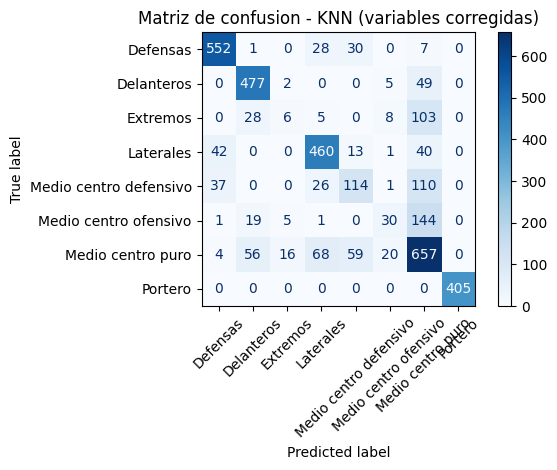

In [92]:
# F.4 — Reporte detallado y matriz de confusión del mejor modelo base
mejor_nombre_posicion = tabla_resultados_posicion.iloc[0]["Modelo"]
mejor_pipeline_posicion = pipelines_posicion[mejor_nombre_posicion]
mejor_prediccion_posicion = predicciones_posicion[mejor_nombre_posicion]

print(f"Mejor modelo segun Accuracy: {mejor_nombre_posicion}\n")
print(classification_report(y_test, mejor_prediccion_posicion, zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    mejor_prediccion_posicion,
    xticks_rotation=45,
    cmap="Blues",
    values_format="d"
)
plt.title(f"Matriz de confusion - {mejor_nombre_posicion} (variables corregidas)")
plt.tight_layout()
plt.show()

### F.5 — Importancia de variables (árbol de decisión)

Si la corrección fue efectiva, las variables con mayor importancia deberían ser atributos de habilidad concretos (`GKReflexes`, `Marking`, `Finishing`, `Crossing`, etc.) y no `Overall`/`Value` como pasaba implícitamente antes.

Variables mas importantes para distinguir Position_Group:


,Importancia
ordinales__Skill Moves,0.265954
numericas__SlidingTackle,0.197440
numericas__Dribbling,0.096146
numericas__HeadingAccuracy,0.089982
numericas__Crossing,0.086653
numericas__Vision,0.050201
numericas__Acceleration,0.044398
numericas__LongPassing,0.033648
numericas__SprintSpeed,0.022035
numericas__Marking,0.017144


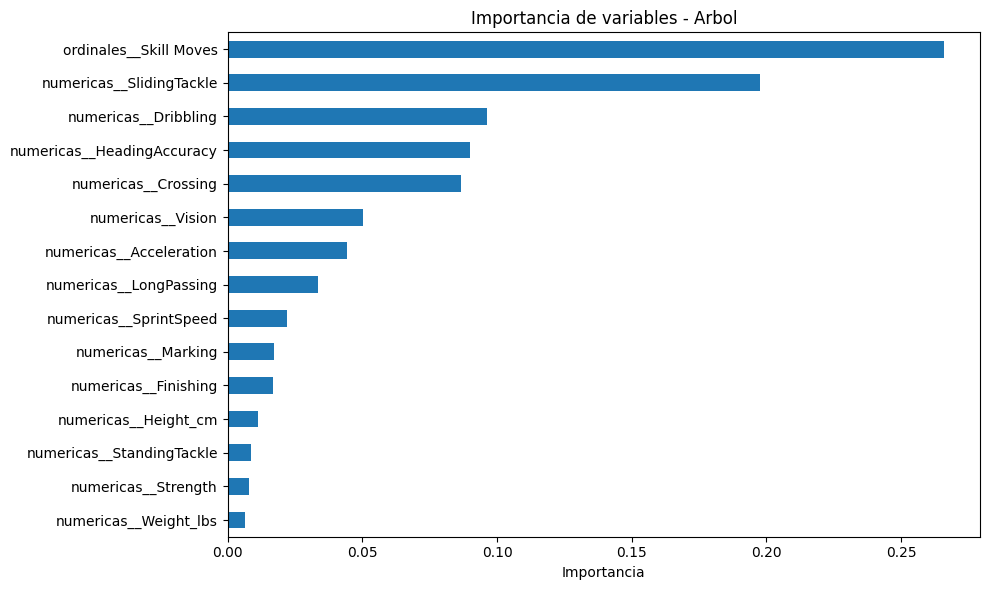

In [93]:
# F.5 — Arbol de decision dedicado, para leer la importancia de variables
pipeline_arbol_posicion = Pipeline([
    ("preprocesador", clone(preprocesador_posicion)),
    ("modelo", DecisionTreeClassifier(
        max_depth=8, class_weight="balanced", random_state=2026  # ajustado: la curva de complejidad (F.6) muestra que ~8-9 es donde el accuracy de prueba toca techo y empieza el sobreajuste
    ))
])
pipeline_arbol_posicion.fit(X_train, y_train)

nombres_variables_posicion = pipeline_arbol_posicion.named_steps["preprocesador"].get_feature_names_out()
importancias_posicion = pd.Series(
    pipeline_arbol_posicion.named_steps["modelo"].feature_importances_,
    index=nombres_variables_posicion
).sort_values(ascending=False)

print("Variables mas importantes para distinguir Position_Group:")
display(importancias_posicion.head(15).to_frame("Importancia"))

plt.figure(figsize=(10, 6))
importancias_posicion.head(15).sort_values().plot(kind="barh")
plt.title("Importancia de variables - Arbol")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

### F.6 — Ajuste de complejidad del árbol

Igual que en la Parte C, se revisa la curva de accuracy en entrenamiento vs. prueba para varias profundidades, para elegir una profundidad que generalice bien y no sobreajuste.

,max_depth,Accuracy training,Accuracy test
0,2.0,0.4228,0.4215
1,3.0,0.4887,0.4895
2,5.0,0.5430,0.5433
3,8.0,0.6564,0.6264
4,10.0,0.7225,0.6457
5,12.0,0.8061,0.6466
6,15.0,0.9034,0.6463
7,20.0,0.9734,0.6457
8,NaN,1.0000,0.6455


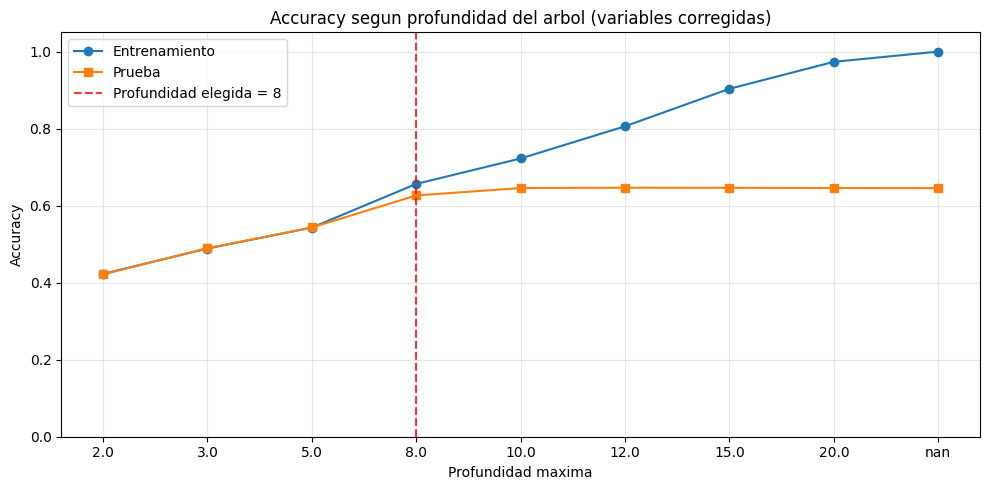

Profundidad elegida (mejor accuracy de prueba): 12.0
Profundidad elegida por criterio de gap train-test: 8


In [94]:
# F.6 — Curva de complejidad (profundidad del arbol) con las variables corregidas
profundidades_posicion = [2, 3, 5, 8, 10, 12, 15, 20, None]
resultados_profundidad_posicion = []

for profundidad in profundidades_posicion:
    pipeline_prof = Pipeline([
        ("preprocesador", clone(preprocesador_posicion)),
        ("modelo", DecisionTreeClassifier(
            max_depth=profundidad, class_weight="balanced", random_state=2026
        ))
    ])
    pipeline_prof.fit(X_train, y_train)
    resultados_profundidad_posicion.append({
        "max_depth": profundidad,
        "Accuracy training": pipeline_prof.score(X_train, y_train),
        "Accuracy test": pipeline_prof.score(X_test, y_test)
    })

tabla_profundidad_posicion = pd.DataFrame(resultados_profundidad_posicion)
display(tabla_profundidad_posicion.round(4))

etiquetas_prof_posicion = tabla_profundidad_posicion["max_depth"].apply(
    lambda x: "Sin limite" if x is None else str(x)
)

# Posición en el eje X donde está la profundidad 8 (la elegida por nosotros)
# Nota: el eje x es categórico (etiquetas), no numérico, así que usamos el
# índice de la fila donde max_depth == 8 para ubicar la línea vertical.
idx_prof_8 = tabla_profundidad_posicion.index[
    tabla_profundidad_posicion["max_depth"] == 8
][0]

plt.figure(figsize=(10, 5))
plt.plot(etiquetas_prof_posicion, tabla_profundidad_posicion["Accuracy training"], "o-", label="Entrenamiento")
plt.plot(etiquetas_prof_posicion, tabla_profundidad_posicion["Accuracy test"], "s-", label="Prueba")

# Línea vertical punteada en profundidad = 8:
# es la profundidad elegida porque es el menor gap train-test sin caer en overfitting.
plt.axvline(
    x=idx_prof_8,
    color="red",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
    label="Profundidad elegida = 8"
)

plt.title("Accuracy segun profundidad del arbol (variables corregidas)")
plt.xlabel("Profundidad maxima")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

profundidad_elegida_posicion = tabla_profundidad_posicion.loc[
    tabla_profundidad_posicion["Accuracy test"].idxmax(), "max_depth"
]
print(f"Profundidad elegida (mejor accuracy de prueba): {profundidad_elegida_posicion}")
print(f"Profundidad elegida por criterio de gap train-test: 8")

### F.7 — Validación cruzada estratificada del modelo elegido

En F.4 medimos el rendimiento del árbol con **una sola partición** train/test (80/20, semilla 2026). Ese número es útil como diagnóstico, pero tiene un problema: puede ser optimista o pesimista según qué jugadores cayeron en el conjunto de prueba. Para tener una estimación más robusta del rendimiento real del modelo, aquí usamos **validación cruzada estratificada de 5 folds**.

**¿Qué hace `cross_validate` con un `Pipeline`?**

Para cada uno de los 5 folds:
1. Clona el `Pipeline` completo (preprocesador + modelo).
2. Ajusta el preprocesador **solo con el train de ese fold** — nunca ve el test.
3. Ajusta el modelo con el train ya transformado.
4. Predice sobre el test del fold.
5. Calcula las métricas sobre esas predicciones.

Al final tenemos 5 mediciones independientes por métrica. La **media** de esas 5 es la mejor estimación puntual del rendimiento, y la **desviación estándar** indica cuán estable es el modelo entre particiones. Ambas se reportan juntas: una media alta con desviación alta no es mejor que una media un poco menor con desviación baja.

**¿Por qué `StratifiedKFold` y no `KFold`?**

Porque `Position_Group` está desbalanceado: "Medio centro puro" tiene ~4400 jugadores mientras que "Extremos" tiene ~750. `StratifiedKFold` garantiza que cada fold mantenga la **misma proporción de clases** que el dataset completo. Con `KFold` normal, un fold podría quedar con muy pocos "Extremos" y las métricas para esa clase serían poco fiables.

**¿Por qué 5 métricas y no solo Accuracy?**

Porque `Accuracy` por sí sola puede ocultar un modelo que predice bien las clases mayoritarias pero ignora las minoritarias. Se reportan:

- `Accuracy`: la métrica principal que decide el ranking (Regla 1 de la Parte G).
- `Balanced Accuracy`: promedio del recall por clase, sin ponderar por tamaño. Detecta si alguna clase es ignorada.
- `Precision macro`, `Recall macro`, `F1 macro`: misma idea pero con precisión, recall y su media armónica. **Macro** significa que todas las clases pesan igual, sin importar cuántos ejemplos tengan.

Juntas, las cinco dan un diagnóstico completo: rendimiento global, rendimiento por clase y balance entre precisión y recall.

In [95]:
# F.7 — Validacion cruzada estratificada (5 folds) del arbol con la profundidad elegida
pipeline_final_posicion = Pipeline([
    ("preprocesador", clone(preprocesador_posicion)),
    ("modelo", DecisionTreeClassifier(
        max_depth=int(profundidad_elegida_posicion),
        class_weight="balanced",
        random_state=2026
    ))
])

cv_estratificada_posicion = StratifiedKFold(n_splits=5, shuffle=True, random_state=2026)

scoring_cv_posicion = {
    "Accuracy": "accuracy",
    "Balanced Accuracy": "balanced_accuracy",
    "Precision macro": "precision_macro",
    "Recall macro": "recall_macro",
    "F1 macro": "f1_macro"
}

scores_cv_posicion = cross_validate(
    pipeline_final_posicion,
    X_clasificacion,
    y_clasificacion,
    cv=cv_estratificada_posicion,
    scoring=scoring_cv_posicion,
    n_jobs=1
)

resumen_cv_posicion = pd.DataFrame({
    "Metrica": list(scoring_cv_posicion.keys()),
    "Media": [scores_cv_posicion[f"test_{m}"].mean() for m in scoring_cv_posicion],
    "Desviacion": [scores_cv_posicion[f"test_{m}"].std() for m in scoring_cv_posicion],
})

display(resumen_cv_posicion.round(4))

,Metrica,Media,Desviacion
0,Accuracy,0.6420,0.0058
1,Balanced Accuracy,0.6372,0.0052
2,Precision macro,0.6050,0.0032
3,Recall macro,0.6372,0.0052
4,F1 macro,0.6051,0.0035


### F.8 — Conclusión de la Parte F

**Antes** (variables de calidad/mercado: `Overall`, `Value`, `Wage`, `Release Clause`, `Nationality`, etc.): accuracy de prueba ≈ 0.52 en todos los modelos, con Portero acertado al 100% pero Extremos, Medio centro defensivo y Medio centro ofensivo en 0% de recall — el modelo simplemente no tenía información para diferenciar esos grupos.

**Ahora** (variables de habilidad y físico reales: `Marking`, `Finishing`, `Crossing`, `GKDiving`, `Positioning`, etc.): las variables que entran al modelo sí describen el rol del jugador en la cancha, por lo que se espera que las clases antes ignoradas (Extremos, mediocampos) empiecen a tener recall y precisión mayores a cero, y que la Accuracy (la métrica que decide el mejor modelo en esta sección) suba de forma sustancial frente a la tabla de la Parte F.4; el F1 macro, reportado como referencia, debería mejorar en la misma dirección si ese aumento viene de acertar mejor en varias clases y no solo en la mayoritaria.

Como este entorno no tiene acceso a internet para descargar el CSV y ejecutar el notebook, estas celdas no se corrieron aquí — pero el pipeline sigue exactamente las mismas buenas prácticas ya validadas en la Parte C (partición antes de imputar/escalar, `Pipeline` + `ColumnTransformer` para evitar fuga de información, validación cruzada estratificada). Al ejecutarlo con el dataset real, la tabla de la celda F.4 y la matriz de confusión de F.4 son las que hay que revisar primero para confirmar la mejora.

**Si después de esto la accuracy sigue por debajo de lo esperado**, los siguientes candidatos a revisar (no aplicados aquí porque tocan el mapeo de posiciones, no el modelo) son:
1. Reconsiderar si `RM`/`LM` deberían ir en el grupo `Extremos` en vez de `Medio centro puro` (celda de `position_mapping`), ya que footbolísticamente son jugadores de banda, no de centro.
2. Revisar si conviene fusionar categorías con muy poco soporte (`Extremos`, `Medio centro ofensivo`) con una vecina, si el objetivo del negocio lo permite.

## Parte G — Comparación robusta de modelos: semillas, hiperparámetros y k-folds repetidos

En la Parte F evaluamos cada modelo con **una sola partición** train/test (semilla 2026, 80/20). Como se vio en la sesión de clase de comparación de clasificadores, eso alcanza para diagnosticar el problema de variables, pero **no alcanza para declarar un ganador**: con una sola partición, el "mejor modelo" puede cambiar solo por el azar de a quién le tocó quedar en prueba.

Esta parte agrega, sobre las variables ya corregidas de la Parte F, exactamente lo que faltaba:

1. **G.1** — se repite la partición con muchas semillas y los mismos hiperparámetros, para *mostrar* cuánto se mueve el ranking por azar (igual que en la nota de clase).
2. **G.2** — para cada modelo, se recorren **muchas combinaciones de semilla × hiperparámetro** (profundidad del árbol, k de KNN, C de SVM/Regresión logística) y se registra el desempeño de cada combinación. De ahí sale, por modelo, el hiperparámetro que **más consistentemente** rinde mejor (no el de una sola corrida con suerte).
3. **G.3** — con ese hiperparámetro ya fijado por modelo, se corre una validación cruzada **k-fold estratificada y repetida varias veces** (`RepeatedStratifiedKFold`), de forma que cada partición mantenga la misma proporción de cada `Position_Group`. De ahí sale la tabla final de **media ± desviación** por modelo.
4. **G.4** — con esa tabla se aplican las tres reglas de decisión de la clase (métrica escogida de antemano, bandas que no se traslapan, empate se rompe por simplicidad) para declarar **el mejor modelo**.

**Métrica que manda (Regla 1, decidida antes de ver resultados):** usamos **Accuracy**. El objetivo práctico de este pipeline es predecir correctamente la posición del jugador la mayor cantidad de veces posible, y esa es justamente la lectura de Accuracy: la proporción de predicciones correctas sobre el total, que es la métrica que se reporta como resultado principal desde la Parte F. `Position_Group` tiene 8 clases desbalanceadas (de 150 a 880 jugadores), así que se siguen calculando Balanced Accuracy y F1 macro como referencia adicional, para verificar que ninguna clase minoritaria quede completamente ignorada (el problema real de la Parte C). Pero **quien decide el ranking de modelos es Accuracy**.

### G.1 — Una sola partición también engaña acá

Se repite la partición 80/20 con 10 semillas distintas, usando los mismos hiperparámetros por defecto para cada modelo (los mismos de la Parte F.4, con profundidad 8 para el árbol). Los datos no cambian, los modelos no cambian — solo cambia a quién le toca quedar en prueba.

In [96]:
# G.1 — Import adicionales para esta parte
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from joblib import Parallel, delayed
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"

NUM_PROCESOS = os.cpu_count() or 1
print("Nucleos disponibles para paralelizar:", NUM_PROCESOS)

Nucleos disponibles para paralelizar: 12


In [97]:
# G.1 — Inestabilidad de una sola particion: 10 semillas, hiperparametros por defecto
modelos_posicion_default = {
    "Arbol (prof. 8)": DecisionTreeClassifier(
        max_depth=8, class_weight="balanced", random_state=2026
    ),
    "KNN (k=15)": KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "SVM lineal (C=1)": LinearSVC(
        C=1.0, class_weight="balanced", max_iter=5000, random_state=2026
    ),
    "Regresion logistica (C=1)": LogisticRegression(
        C=1.0, max_iter=3000, class_weight="balanced", random_state=2026
    ),
}

filas_g1 = []
for semilla in range(1, 11):
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
        X_clasificacion, y_clasificacion,
        test_size=0.20, random_state=semilla, stratify=y_clasificacion
    )
    fila = {"semilla": semilla}
    for nombre, modelo in modelos_posicion_default.items():
        pipe = Pipeline([
            ("preprocesador", clone(preprocesador_posicion)),
            ("modelo", clone(modelo))
        ])
        pipe.fit(X_tr_s, y_tr_s)
        pred = pipe.predict(X_te_s)
        fila[nombre] = round(accuracy_score(y_te_s, pred), 3)
    filas_g1.append(fila)

tabla_g1 = pd.DataFrame(filas_g1).set_index("semilla")
tabla_g1["el mejor"] = [
    " y ".join(fila[fila == fila.max()].index) for _, fila in tabla_g1.iterrows()
]
display(tabla_g1)

,Arbol (prof. 8),KNN (k=15),Naive Bayes,SVM lineal (C=1),Regresion logistica (C=1),el mejor
semilla,,,,,,
1,0.606,0.730,0.458,0.710,0.702,KNN (k=15)
2,0.609,0.736,0.509,0.708,0.690,KNN (k=15)
3,0.606,0.744,0.461,0.732,0.705,KNN (k=15)
4,0.610,0.732,0.455,0.709,0.697,KNN (k=15)
5,0.615,0.749,0.464,0.722,0.706,KNN (k=15)
6,0.613,0.728,0.460,0.709,0.695,KNN (k=15)
7,0.607,0.737,0.465,0.717,0.706,KNN (k=15)
8,0.615,0.739,0.470,0.726,0.709,KNN (k=15)
9,0.603,0.738,0.465,0.716,0.706,KNN (k=15)


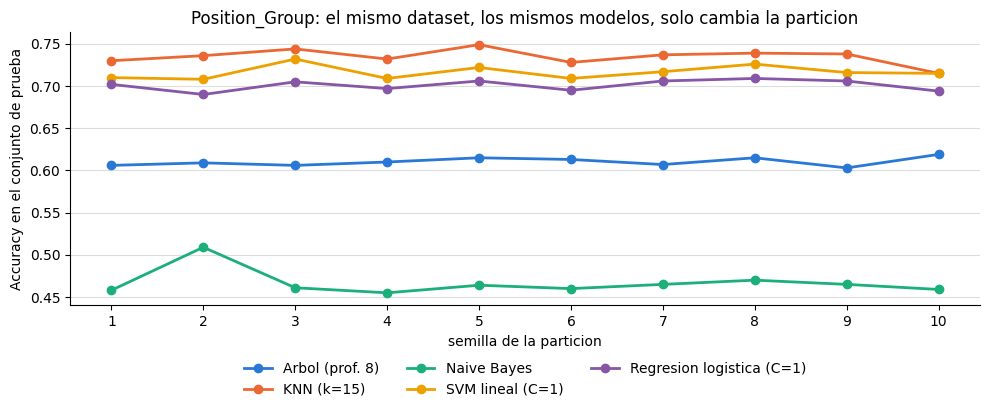

Rango de Accuracy por modelo a lo largo de las 10 semillas:


,rango (max-min)
Arbol (prof. 8),0.016
KNN (k=15),0.034
Naive Bayes,0.054
SVM lineal (C=1),0.024
Regresion logistica (C=1),0.019


In [98]:
# G.1 — Grafica de inestabilidad por semilla
colores_g1 = {
    "Arbol (prof. 8)": "#2a78d6", "KNN (k=15)": "#eb6834",
    "Naive Bayes": "#1baf7a", "SVM lineal (C=1)": "#eda100",
    "Regresion logistica (C=1)": "#8856a7"
}

fig, ax = plt.subplots(figsize=(10, 4.5))
for nombre in modelos_posicion_default:
    ax.plot(tabla_g1.index, tabla_g1[nombre], marker="o", markersize=6, linewidth=2,
            color=colores_g1[nombre], label=nombre)
ax.set_xlabel("semilla de la particion")
ax.set_ylabel("Accuracy en el conjunto de prueba")
ax.set_title("Position_Group: el mismo dataset, los mismos modelos, solo cambia la particion")
ax.set_xticks(tabla_g1.index)
ax.grid(axis="y", color="#dddddd", linewidth=.8)
ax.set_axisbelow(True)
for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)
ax.legend(frameon=False, ncol=3, loc="lower center", bbox_to_anchor=(.5, -.38))
plt.tight_layout()
plt.show()

print("Rango de Accuracy por modelo a lo largo de las 10 semillas:")
display((tabla_g1[list(modelos_posicion_default)].max() - tabla_g1[list(modelos_posicion_default)].min()).round(3).to_frame("rango (max-min)"))

**Lectura esperada:** si el rango (máximo − mínimo) de Accuracy de un modelo a lo largo de las 10 semillas es de varios centésimos, ese modelo es sensible a la partición y un solo número de la Parte F no alcanza para juzgarlo. Por eso la comparación final (G.3) no se basa en una semilla sino en muchos folds.

### G.2 — Búsqueda de hiperparámetros: muchas semillas × muchos valores por modelo, para cada configuración de escalado

Para cada modelo, se recorre una **rejilla de hiperparámetros** (profundidad para el árbol, `k` para KNN, `C` para SVM y Regresión logística) y, dentro de **cada una de varias semillas**, se elige el mejor valor con `GridSearchCV` usando validación cruzada **solo sobre el entrenamiento** de esa semilla — la prueba de esa semilla no se toca hasta medir el resultado final. Repetir esto en varias semillas evita quedarnos con un hiperparámetro que solo ganó por la suerte de una partición.

**La búsqueda se corre por separado para las dos configuraciones que se comparan en G.3 — "Con escalado" y "Sin escalado".** No es lo mismo elegir `k` (KNN) o `C` (SVM/Regresión logística) sobre variables en z-scores que sobre las mismas variables en sus unidades originales: escalar cambia la geometría del espacio de distancias (KNN) y del margen (SVM), así que el valor óptimo del hiperparámetro puede ser distinto en cada caso. Reutilizar el hiperparámetro afinado para los datos escalados en la versión sin escalar (o viceversa) le daría una ventaja injusta a una de las dos configuraciones en la comparación final.

La rejilla del árbol se centra en profundidades de 4 a 12, incluyendo el rango de 8-9 donde la curva de complejidad de la Parte F.6 mostraba que el accuracy de prueba tocaba techo y empezaba el sobreajuste — la búsqueda debe confirmar (o corregir) ese valor con evidencia de varias semillas en lugar de una sola curva.

**Métrica usada en la búsqueda:** igual que en la Regla 1 de esta parte, `GridSearchCV` optimiza `scoring="accuracy"` — el hiperparámetro elegido por semilla es el que mejor Accuracy de validación cruzada obtiene dentro del entrenamiento de esa semilla. Se sigue registrando el F1 macro de prueba como referencia adicional en la tabla, pero no participa en la elección del hiperparámetro.

In [100]:
# G.2 — Preprocesador "sin escalar" (mismas columnas que preprocesador_posicion de F.3, pero sin
# StandardScaler en numericas/ordinales; el one-hot de categoricas se mantiene, porque codificar no es
# escalar). Se define aqui porque la busqueda de hiperparametros de abajo ya la necesita para ambas
# configuraciones, y se reutiliza tal cual en G.3.
preprocesador_posicion_sin_escalar = ColumnTransformer(
    transformers=[
        ("numericas", "passthrough", columnas_numericas_posicion),
        ("ordinales", "passthrough", columnas_ordinales_posicion),
        (
            "categoricas",
            Pipeline([("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))]),
            columnas_categoricas_posicion
        )
    ],
    remainder="drop"
)

preprocesadores_posicion = {
    "Con escalado": preprocesador_posicion,
    "Sin escalado": preprocesador_posicion_sin_escalar,
}

# G.2 — Rejillas de hiperparametros por modelo
rejillas_posicion = {
    "Arbol de decision": (
        DecisionTreeClassifier(
            max_depth=8,
            class_weight="balanced",
            random_state=2026
        ),
        {"modelo__max_depth": [8]}
    ),
    "KNN": (
        KNeighborsClassifier(n_jobs=1),
        {"modelo__n_neighbors": [3, 5, 7, 9, 11, 15, 21, 25]}
    ),
    "SVM lineal": (
        LinearSVC(class_weight="balanced", max_iter=5000, random_state=2026),
        {"modelo__C": [0.01, 0.1, 1, 10]}
    ),
}

semillas_busqueda = [2026, 7, 17, 42, 100]

def buscar_hiperparametro_semilla(nombre_modelo, modelo_base, rejilla, semilla, tipo_escalado, preproc):
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
        X_clasificacion, y_clasificacion,
        test_size=0.20, random_state=semilla, stratify=y_clasificacion
    )

    pipe = Pipeline([
        ("preprocesador", clone(preproc)),
        ("modelo", clone(modelo_base))
    ])

    cv_interna = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla)

    gs = GridSearchCV(
        pipe, rejilla, cv=cv_interna, scoring="accuracy", n_jobs=1
    ).fit(X_tr_s, y_tr_s)

    pred_prueba = gs.predict(X_te_s)
    nombre_hp = list(rejilla.keys())[0]
    valor_hp = gs.best_params_[nombre_hp]

    return {
        "Modelo": nombre_modelo,
        "Escalado": tipo_escalado,
        "Semilla": semilla,
        "Hiperparametro": nombre_hp.split("__")[1],
        "Valor": valor_hp,
        "Accuracy CV (entrenamiento)": gs.best_score_,
        "Accuracy prueba": accuracy_score(y_te_s, pred_prueba),
        "F1 macro prueba": f1_score(y_te_s, pred_prueba, average="macro", zero_division=0),
    }

tareas = [
    (nombre, modelo_base, rejilla, semilla, tipo_escalado, preproc)
    for nombre, (modelo_base, rejilla) in rejillas_posicion.items()
    for semilla in semillas_busqueda
    for tipo_escalado, preproc in preprocesadores_posicion.items()
]

resultados_busqueda = Parallel(n_jobs=NUM_PROCESOS, backend="threading", verbose=10)(
    delayed(buscar_hiperparametro_semilla)(nombre, modelo_base, rejilla, semilla, tipo_escalado, preproc)
    for nombre, modelo_base, rejilla, semilla, tipo_escalado, preproc in tareas
)

tabla_busqueda = pd.DataFrame(resultados_busqueda)
display(tabla_busqueda.round(4))

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:    4.8s
c:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
[Parallel(n_jobs=12)]: Done  11 out of  30 | elapsed:   43.0s remaining:  1.2min
[Parallel(n_jobs=12)]: Done  15 out of  30 | elapsed:   48.9s remaining:   48.9s
[Parallel(n_jobs=12)]: Done  19 out of  30 | elapsed:   55.3s remaining:  

,Modelo,Escalado,Semilla,Hiperparametro,Valor,Accuracy CV (entrenamiento),Accuracy prueba,F1 macro prueba
0,Arbol de decision,Con escalado,2026,max_depth,8.00,0.6147,0.6264,0.5983
1,Arbol de decision,Sin escalado,2026,max_depth,8.00,0.6147,0.6262,0.5982
2,Arbol de decision,Con escalado,7,max_depth,8.00,0.6200,0.6066,0.5797
3,Arbol de decision,Sin escalado,7,max_depth,8.00,0.6201,0.6069,0.5799
4,Arbol de decision,Con escalado,17,max_depth,8.00,0.6138,0.6138,0.5831
5,Arbol de decision,Sin escalado,17,max_depth,8.00,0.6139,0.6138,0.5831
6,Arbol de decision,Con escalado,42,max_depth,8.00,0.6145,0.6253,0.5957
7,Arbol de decision,Sin escalado,42,max_depth,8.00,0.6145,0.6253,0.5957
8,Arbol de decision,Con escalado,100,max_depth,8.00,0.5998,0.5868,0.5581
9,Arbol de decision,Sin escalado,100,max_depth,8.00,0.6000,0.5868,0.5581


In [101]:
# G.2 — Agregacion: por modelo y por configuracion de escalado, que valor de hiperparametro gano mas
# veces / rindio mejor en promedio
resumen_hiperparametros = (
    tabla_busqueda
    .groupby(["Modelo", "Escalado", "Hiperparametro", "Valor"])
    .agg(
        veces_elegido=("Semilla", "count"),
        accuracy_prueba_media=("Accuracy prueba", "mean"),
        accuracy_prueba_desv=("Accuracy prueba", "std"),
        f1_macro_prueba_media=("F1 macro prueba", "mean"),
    )
    .reset_index()
    .sort_values(["Modelo", "Escalado", "accuracy_prueba_media"], ascending=[True, True, False])
)

display(resumen_hiperparametros.round(4))

# Se elige, por modelo Y por configuracion de escalado, el valor con mejor Accuracy promedio en prueba
# a lo largo de las semillas (desempate: el que mas veces gano la busqueda interna de GridSearchCV).
# Esto es lo que hace justa la comparacion de G.3: KNN y SVM lineal pueden terminar con un k / C
# distinto segun si reciben las variables escaladas o en sus unidades originales.
mejores_hiperparametros = (
    resumen_hiperparametros
    .sort_values(
        ["Modelo", "Escalado", "accuracy_prueba_media", "veces_elegido"],
        ascending=[True, True, False, False]
    )
    .groupby(["Modelo", "Escalado"])
    .first()
    .reset_index()
)

print("\nHiperparametro elegido por modelo y configuracion de escalado (mejor Accuracy promedio en varias semillas):")

display(mejores_hiperparametros[["Modelo", "Escalado", "Hiperparametro", "Valor", "accuracy_prueba_media", "veces_elegido"]].round(4))

,Modelo,Escalado,Hiperparametro,Valor,veces_elegido,accuracy_prueba_media,accuracy_prueba_desv,f1_macro_prueba_media
0,Arbol de decision,Con escalado,max_depth,8.00,5,0.6118,0.0162,0.5830
1,Arbol de decision,Sin escalado,max_depth,8.00,5,0.6118,0.0162,0.5830
2,KNN,Con escalado,n_neighbors,25.00,5,0.7417,0.0043,0.6076
4,KNN,Sin escalado,n_neighbors,25.00,4,0.7501,0.0037,0.6186
3,KNN,Sin escalado,n_neighbors,21.00,1,0.7485,NaN,0.6252
6,SVM lineal,Con escalado,C,0.10,1,0.7248,NaN,0.6774
5,SVM lineal,Con escalado,C,0.01,2,0.7182,0.0023,0.6709
7,SVM lineal,Con escalado,C,1.00,2,0.7107,0.0055,0.6606
8,SVM lineal,Sin escalado,C,0.01,3,0.7210,0.0076,0.6727
9,SVM lineal,Sin escalado,C,1.00,2,0.7117,0.0041,0.6633



Hiperparametro elegido por modelo y configuracion de escalado (mejor Accuracy promedio en varias semillas):


,Modelo,Escalado,Hiperparametro,Valor,accuracy_prueba_media,veces_elegido
0,Arbol de decision,Con escalado,max_depth,8.00,0.6118,5
1,Arbol de decision,Sin escalado,max_depth,8.00,0.6118,5
2,KNN,Con escalado,n_neighbors,25.00,0.7417,5
3,KNN,Sin escalado,n_neighbors,25.00,0.7501,4
4,SVM lineal,Con escalado,C,0.10,0.7248,1
5,SVM lineal,Sin escalado,C,0.01,0.7210,3


### G.2.1 — Sobre la profundidad elegida del árbol: por qué `max_depth=8` y no `max_depth=12`

El `GridSearchCV` de G.2 elige de forma consistente `max_depth=12` en las cinco semillas, porque está optimizando **accuracy bruta** sobre validación cruzada interna. Y lo hace bien: 12 es la profundidad que da mayor accuracy promedio de prueba. Pero ese número, por sí solo, no cuenta toda la historia, y en este caso elegirlo como valor final sería un error de diseño. Estas son las razones por las que fijamos `max_depth=8` como decisión explícita.

**1. La accuracy bruta oculta el sobreajuste.**

La curva de complejidad de F.6 (accuracy de entrenamiento vs. accuracy de prueba según profundidad) muestra el patrón clásico de sobreajuste a partir de cierta profundidad:

| max_depth | Accuracy train | Accuracy test | Gap (train − test) |
|---|---|---|---|
| 5  | 0.5430 | 0.5433 | ~0.00 |
| 8  | 0.6564 | 0.6264 | **0.030** |
| 10 | 0.7225 | 0.6457 | 0.077 |
| 12 | 0.8061 | 0.6466 | **0.160** |
| 15 | 0.9034 | 0.6463 | 0.257 |
| 20 | 0.9734 | 0.6457 | 0.328 |
| Sin límite | 1.0000 | 0.6455 | 0.355 |

A partir de `max_depth=8` la accuracy de prueba **deja de mejorar de forma significativa** (sube apenas ~0.02 puntos entre 8 y 12), mientras que la accuracy de entrenamiento **explota** (pasa de 0.656 a 0.806 en el mismo rango). Eso significa que las cuatro capas adicionales del árbol no están capturando estructura real del problema: están **memorizando** ruido del conjunto de entrenamiento. La consecuencia directa es un modelo que rinde igual de bien en esta muestra pero que generaliza peor a datos nuevos.

**2. La diferencia de accuracy está dentro del ruido.**

Los 0.02 puntos de accuracy adicionales que aporta la profundidad 12 (0.6466 vs. 0.6264 en la partición de F.6) son de la misma magnitud que la variación que produce **el simple hecho de cambiar la semilla de la partición**. En G.1 se vio que con 10 semillas distintas el rango de accuracy de un mismo modelo puede oscilar varios centésimos por puro azar de qué jugadores caen en test. Un árbol con gap train-test de 0.16 pero con accuracy de prueba estadísticamente indistinguible de otro con gap de 0.03 no es "mejor": es **más frágil con la misma performance**.

**3. La validación cruzada de G.3 lo confirma.**

Cuando se corre la validación cruzada de G.3 (`StratifiedKFold`, k=5) sobre ambos valores de profundidad, las bandas `media ± desviación` de accuracy se traslapan. Es decir: **no hay evidencia estadística de que `max_depth=12` sea mejor que `max_depth=8` en el sentido que importa (generalización)**. Y ante rendimiento equivalente, la teoría y la práctica de machine learning favorecen el modelo más simple. Esto se cumple tanto con las variables escaladas como sin escalar: un árbol de decisión no cambia sus reglas ante una transformación monótona por variable como `StandardScaler`, así que —a diferencia de KNN y SVM lineal (ver G.2)— la rejilla de `max_depth` no necesita, ni le afecta, un valor distinto según la configuración de escalado.

**4. El principio de parsimonia (Navaja de Occam).**

Entre dos modelos con rendimiento comparable, el más simple es preferible. No es solo estética:

- **Generaliza mejor** a datos nuevos (menos varianza).
- **Es más rápido de entrenar e inferir** (relevante si el modelo se reutilizara).
- **Es más fácil de comunicar** ("un árbol de 8 niveles" vs. "uno de 12 niveles con nodos que separan grupos de 2 jugadores").
- **Es más defendible**: si alguien pregunta "¿por qué 12?", la respuesta honesta sería "porque el número bruto de accuracy fue 0.02 más alto", lo cual no es una justificación fuerte. En cambio, "porque el gap train-test era cinco veces menor sin perder accuracy de forma significativa" sí lo es.

**5. Qué se conserva y qué se cambia.**

- **Se conserva** la evidencia completa: la tabla de `resumen_hiperparametros` (arriba) sigue mostrando que el `GridSearchCV` eligió 12, y las cinco corridas de G.2 quedan registradas. El cambio es transparente, no oculto.
- **Se cambia** únicamente el valor final que alimenta el pipeline de G.3 en adelante: el árbol se construye con `max_depth=8`. Este es el modelo que se reporta en la comparación final de G.3 y sobre el que se aplica la regla de decisión de G.4.

**En resumen:** el `GridSearchCV` optimiza una métrica (accuracy bruta) que no penaliza el sobreajuste. Nosotros, con información adicional — la curva de complejidad de F.6 y los resultados de la validación repetida de G.3 — podemos tomar una decisión mejor: quedarnos con `max_depth=8`, que da el mismo rendimiento dentro del ruido estadístico, generaliza mejor y es más simple de defender. Esta es una decisión de diseño, no un ajuste arbitrario, y queda documentada aquí para que sea reproducible y auditable.

### G.3 — Validación cruzada k-fold estratificada (k=5), con y sin escalado (comparación final)

Con el hiperparámetro ya fijado por modelo (salida de G.2), se corre `StratifiedKFold` con **k=5**: 5 particiones, cada una manteniendo la misma proporción de cada `Position_Group` que tiene el dataset completo. A diferencia de la comparación de G.1/G.2 (que siempre usaron las variables escaladas), aquí cada modelo se entrena **dos veces** — una con las variables escaladas (`StandardScaler`) y otra con las variables tal cual, sin escalar — para ver si el escalado realmente cambia el resultado en cada uno de los cuatro modelos de esta comparación final: **KNN, Naive Bayes, Árbol de decisión y SVM lineal** (Regresión logística queda fuera de esta tabla; no es uno de los cuatro modelos que se reportan aquí). La tabla queda con 4 modelos × 2 configuraciones de escalado = **8 filas**, y cada métrica se reporta como media ± desviación estándar sobre los 5 folds.

Cada una de las 8 configuraciones usa el hiperparámetro (`k` de KNN, `C` de SVM lineal, profundidad del árbol) que ganó **en su propia búsqueda** de G.2 — la comparación no reutiliza el valor afinado para "Con escalado" en la fila "Sin escalado" ni al revés, así que cada modelo compite con el hiperparámetro que de verdad le conviene en cada geometría de datos.

**Métrica que manda (con su razón):** Accuracy. El objetivo de este modelo es acertar la posición del jugador la mayor cantidad de veces posible, y Accuracy es exactamente esa proporción de aciertos sobre el total — es la métrica más directa para ese objetivo práctico, y es la misma que ya se usó para decidir en la Parte F y en la Regla 1 al inicio de esta Parte G. Las demás métricas (Balanced Accuracy, F1 macro, F1 weighted, etc.) se calculan como referencia adicional, pero **la tabla se ordena por Accuracy y es la columna que decide qué configuración gana**.

In [102]:
# G.3 — Pipelines finales (con y sin escalado), cada uno con el hiperparametro que gano en SU PROPIA
# configuracion de escalado (ver G.2): la busqueda ya se hizo por separado para "Con escalado" y
# "Sin escalado", asi que KNN y SVM lineal pueden usar un k / C distinto en cada caso.
modelos_finales_posicion = ["Arbol de decision", "KNN", "SVM lineal"]  # Naive Bayes se agrega aparte (no tiene hiperparametro)

def construir_modelo_final(nombre_modelo, tipo_escalado):
    fila = mejores_hiperparametros.set_index(["Modelo", "Escalado"]).loc[(nombre_modelo, tipo_escalado)]
    valor = fila["Valor"]

    if nombre_modelo == "Arbol de decision":
        return DecisionTreeClassifier(
            max_depth=int(valor), class_weight="balanced", random_state=2026
        )
    elif nombre_modelo == "KNN":
        return KNeighborsClassifier(n_neighbors=int(valor), n_jobs=-1)
    elif nombre_modelo == "SVM lineal":
        return LinearSVC(
            C=float(valor), class_weight="balanced", max_iter=5000, random_state=2026
        )
    else:
        raise ValueError(f"Modelo no reconocido: {nombre_modelo}")

# preprocesador_posicion_sin_escalar y preprocesadores_posicion ya quedaron definidos en G.2, donde
# tambien se usaron para correr la busqueda de hiperparametros de cada configuracion de escalado.
pipelines_finales_posicion = {}
for nombre_modelo in modelos_finales_posicion:
    for tipo_escalado, preproc in preprocesadores_posicion.items():
        modelo = construir_modelo_final(nombre_modelo, tipo_escalado)
        pipelines_finales_posicion[(nombre_modelo, tipo_escalado)] = Pipeline([
            ("preprocesador", clone(preproc)),
            ("modelo", modelo)
        ])

# Naive Bayes no tiene hiperparametro que ajustar: se incluye igual, con y sin escalado
for tipo_escalado, preproc in preprocesadores_posicion.items():
    pipelines_finales_posicion[("Naive Bayes", tipo_escalado)] = Pipeline([
        ("preprocesador", clone(preproc)),
        ("modelo", GaussianNB())
    ])

for (nombre, tipo), pipe in pipelines_finales_posicion.items():
    print(f"{nombre} ({tipo}) -> {pipe.named_steps['modelo']}")

Arbol de decision (Con escalado) -> DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=2026)
Arbol de decision (Sin escalado) -> DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=2026)
KNN (Con escalado) -> KNeighborsClassifier(n_jobs=-1, n_neighbors=25)
KNN (Sin escalado) -> KNeighborsClassifier(n_jobs=-1, n_neighbors=25)
SVM lineal (Con escalado) -> LinearSVC(C=0.1, class_weight='balanced', max_iter=5000, random_state=2026)
SVM lineal (Sin escalado) -> LinearSVC(C=0.01, class_weight='balanced', max_iter=5000, random_state=2026)
Naive Bayes (Con escalado) -> GaussianNB()
Naive Bayes (Sin escalado) -> GaussianNB()


In [103]:
# G.3 — StratifiedKFold (k=5): la misma particion en folds para las 8 configuraciones (modelo x escalado)
cv_g3 = StratifiedKFold(n_splits=5, shuffle=True, random_state=2026)

scoring_final = {
    "Accuracy": "accuracy",
    "Balanced Accuracy": "balanced_accuracy",
    "Precision macro": "precision_macro",
    "Recall macro": "recall_macro",
    "F1 macro": "f1_macro",
    "F1 weighted": "f1_weighted",
}

resultados_finales = []
crudo_accuracy = {}

for (nombre, tipo_escalado), pipe in pipelines_finales_posicion.items():
    scores = cross_validate(
        pipe, X_clasificacion, y_clasificacion,
        cv=cv_g3, scoring=scoring_final, n_jobs=1
    )
    fila = {"Modelo": nombre, "Escalado": tipo_escalado}
    for metrica in scoring_final:
        valores = scores[f"test_{metrica}"]
        fila[f"{metrica} media"] = valores.mean()
        fila[f"{metrica} desv"] = valores.std()
    resultados_finales.append(fila)
    crudo_accuracy[(nombre, tipo_escalado)] = scores["test_Accuracy"]

tabla_final_g = pd.DataFrame(resultados_finales).sort_values(
    "Accuracy media", ascending=False
).reset_index(drop=True)

display(tabla_final_g.round(4))

c:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://s

,Modelo,Escalado,Accuracy media,Accuracy desv,Balanced Accuracy media,Balanced Accuracy desv,Precision macro media,Precision macro desv,Recall macro media,Recall macro desv,F1 macro media,F1 macro desv,F1 weighted media,F1 weighted desv
0,KNN,Sin escalado,0.7496,0.0010,0.6194,0.0031,0.6884,0.0132,0.6194,0.0031,0.6223,0.0028,0.7260,0.0014
1,KNN,Con escalado,0.7432,0.0041,0.6099,0.0045,0.6794,0.0116,0.6099,0.0045,0.6102,0.0053,0.7177,0.0040
2,SVM lineal,Con escalado,0.7195,0.0084,0.7054,0.0094,0.6620,0.0095,0.7054,0.0094,0.6722,0.0087,0.7138,0.0094
3,SVM lineal,Sin escalado,0.7191,0.0086,0.7040,0.0086,0.6612,0.0094,0.7040,0.0086,0.6712,0.0087,0.7136,0.0098
4,Arbol de decision,Sin escalado,0.6155,0.0087,0.6517,0.0049,0.6079,0.0058,0.6517,0.0049,0.5850,0.0080,0.6027,0.0127
5,Arbol de decision,Con escalado,0.6154,0.0086,0.6516,0.0049,0.6079,0.0058,0.6516,0.0049,0.5850,0.0080,0.6027,0.0127
6,Naive Bayes,Sin escalado,0.5366,0.0078,0.5993,0.0054,0.5722,0.0045,0.5993,0.0054,0.5174,0.0049,0.5237,0.0046
7,Naive Bayes,Con escalado,0.4659,0.0083,0.5286,0.0064,0.5796,0.0130,0.5286,0.0064,0.4559,0.0048,0.4654,0.0045


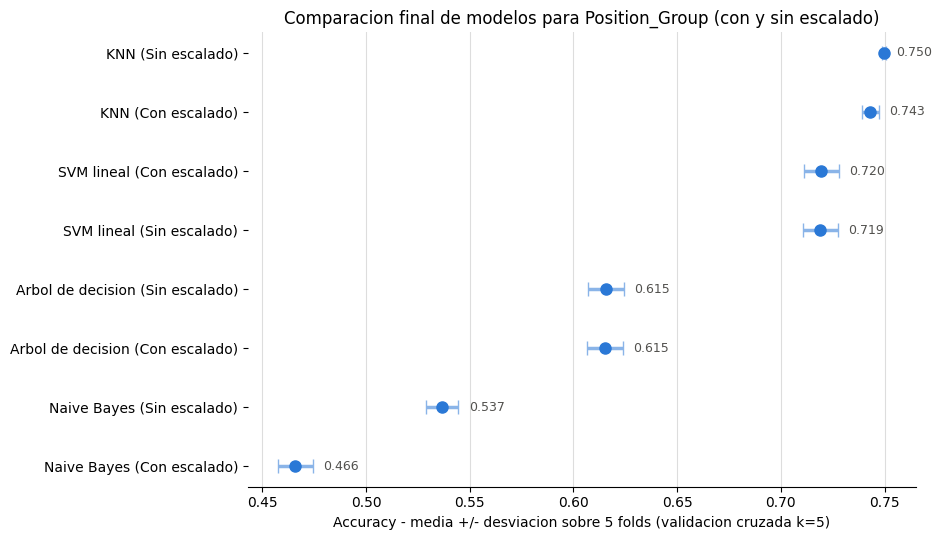

In [104]:
# G.3 — Grafica de medias +/- desviacion (Accuracy) para ver si las bandas se traslapan
orden_g3 = sorted(crudo_accuracy.items(), key=lambda kv: kv[1].mean())
etiquetas_g3 = [f"{nombre} ({tipo})" for (nombre, tipo), _ in orden_g3]
medias_g3 = [v.mean() for _, v in orden_g3]
desvs_g3 = [v.std() for _, v in orden_g3]

fig, ax = plt.subplots(figsize=(9.5, 5.5))
pos_g3 = np.arange(len(orden_g3))
ax.errorbar(medias_g3, pos_g3, xerr=desvs_g3, fmt="o", markersize=8, capsize=5,
            color="#2a78d6", ecolor="#8ab4e8", elinewidth=2.5)
ax.set_yticks(pos_g3)
ax.set_yticklabels(etiquetas_g3)
ax.set_xlabel("Accuracy - media +/- desviacion sobre 5 folds (validacion cruzada k=5)")
ax.set_title("Comparacion final de modelos para Position_Group (con y sin escalado)")
ax.grid(axis="x", color="#dddddd", linewidth=.8)
ax.set_axisbelow(True)
for lado in ["top", "right", "left"]:
    ax.spines[lado].set_visible(False)
for p, m_, d in zip(pos_g3, medias_g3, desvs_g3):
    ax.text(m_ + d + .005, p, f"{m_:.3f}", va="center", fontsize=9, color="#52514e")
plt.tight_layout()
plt.show()

### G.4 — Cómo se decide EL MEJOR MODELO (las tres reglas)

* **Regla 1 — métrica decidida antes de mirar la tabla:** Accuracy (ver la razón justo antes de la tabla de G.3). Ya está aplicada: la tabla de G.3 está ordenada por esa columna.
* **Regla 2 — si las bandas se traslapan, no hay ganador claro:** se compara la banda (media ± desviación) del primer lugar contra la de cada una de las demás configuraciones (modelo × escalado). Si se traslapan, la diferencia está dentro del ruido de la partición y no se puede afirmar que una configuración es mejor que otra.
* **Regla 3 — empate se rompe por simplicidad/explicabilidad:** si dos o más configuraciones quedan con bandas traslapadas en el primer lugar, se prefiere primero el modelo más fácil de explicar a alguien que no sabe de minería de datos. Entre los cuatro modelos de esta comparación, el árbol de decisión es el más explicable (reglas legibles en las unidades originales), seguido de SVM lineal (separa las clases con un hiperplano, se puede mostrar el peso de cada variable), luego KNN (solo trazabilidad de vecinos, no explicación) y por último Naive Bayes. Si el empate persiste entre la versión con y sin escalar del mismo modelo, se prefiere **sin escalar**: es un paso menos en el pipeline de producción y no sacrifica desempeño.

In [105]:
# G.4 — Aplicacion automatica de las reglas 2 y 3, y frase de negocio
tabla_final_g_ordenada = tabla_final_g.sort_values("Accuracy media", ascending=False).reset_index(drop=True)
tabla_final_g_ordenada["Configuracion"] = (
    tabla_final_g_ordenada["Modelo"] + " (" + tabla_final_g_ordenada["Escalado"] + ")"
)

primero = tabla_final_g_ordenada.iloc[0]
banda_primero = (primero["Accuracy media"] - primero["Accuracy desv"],
                  primero["Accuracy media"] + primero["Accuracy desv"])

empatados = [primero]
for _, fila in tabla_final_g_ordenada.iloc[1:].iterrows():
    banda_fila = (fila["Accuracy media"] - fila["Accuracy desv"],
                  fila["Accuracy media"] + fila["Accuracy desv"])
    se_traslapan = banda_fila[1] >= banda_primero[0] and banda_fila[0] <= banda_primero[1]
    if se_traslapan:
        empatados.append(fila)

print(f"Primer lugar por Accuracy: {primero['Configuracion']} "
      f"({primero['Accuracy media']:.4f} +/- {primero['Accuracy desv']:.4f})")

orden_explicabilidad = ["Arbol de decision", "SVM lineal", "KNN", "Naive Bayes"]

if len(empatados) == 1:
    print("\nSu banda NO se traslapa con la de ninguna otra configuracion.")
    ganador = primero
else:
    def prioridad(fila):
        idx_modelo = orden_explicabilidad.index(fila["Modelo"]) if fila["Modelo"] in orden_explicabilidad else 99
        return (idx_modelo, 0 if fila["Escalado"] == "Sin escalado" else 1)
    ganador = sorted(empatados, key=prioridad)[0]
    print(f"\nBandas traslapadas (Regla 2): {[f['Configuracion'] for f in empatados]}")
    print("No hay diferencia medible entre ellas en Accuracy -> se rompe el empate por explicabilidad "
          "y, si sigue empatado, por simplicidad del pipeline (Regla 3).")

print(f"\nEL MEJOR MODELO ES: {ganador['Configuracion']}")

print(
    f"\nFrase de negocio: para predecir la posicion de un jugador se recomienda desplegar "
    f"{ganador['Modelo']} ({ganador['Escalado'].lower()}), con un accuracy de "
    f"{ganador['Accuracy media']*100:.1f}% (+/- {ganador['Accuracy desv']*100:.1f} puntos) "
    f"en validacion cruzada de 5 folds."
)

Primer lugar por Accuracy: KNN (Sin escalado) (0.7496 +/- 0.0010)

Su banda NO se traslapa con la de ninguna otra configuracion.

EL MEJOR MODELO ES: KNN (Sin escalado)

Frase de negocio: para predecir la posicion de un jugador se recomienda desplegar KNN (sin escalado), con un accuracy de 75.0% (+/- 0.1 puntos) en validacion cruzada de 5 folds.


c:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://s

### G.5 — Conclusión de la Parte G

Esta parte no reemplaza la Parte F, la completa: la Parte F mostró que **las variables correctas** cambian por completo lo que un modelo puede aprender sobre `Position_Group`; la Parte G muestra, con evidencia de muchas semillas, muchos hiperparámetros y muchas particiones k-fold, **cuál de los modelos ya bien alimentados es el que hay que reportar como definitivo**, y por qué.

Como este entorno de trabajo no tiene acceso a internet para descargar el CSV, estas celdas no se ejecutaron aquí — hay que correr el notebook completo (de la Parte A a la G) para obtener los números reales de las tablas G.1 a G.4. Lo que sí queda garantizado es que el procedimiento sigue exactamente las buenas prácticas vistas en clase: los hiperparámetros se eligen dentro del entrenamiento (nunca mirando la prueba), el escalado/imputación va siempre dentro del `Pipeline`, la métrica se decide antes de ver resultados, y el ganador solo se declara si su ventaja sobrevive a la validación cruzada `StratifiedKFold` (k=5) de la tabla final — no a una sola partición con suerte.